# Three-Tier HP Prediction Model

## Model Architecture:
- **Low-CR Model (CR ≤ 1)**: Optimized for very low CR creatures
- **Mid-CR Model (1 < CR ≤ 12)**: Standard model for most creatures
- **High-CR Model (CR > 12)**: Handles legendary/epic creatures

Each model uses the same three-phase approach but with different constraints tuned for their CR range.

In [56]:
# Detect execution context and set paths dynamically
import os
from pathlib import Path

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = 'data'
    PICKLED_MODELS_DIR = 'pickled_models'
    MONSTER_BUILDER_DIR = 'monster-builder-v2'

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")


📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: data
   Models directory: pickled_models


In [57]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d
from scipy.optimize import minimize, LinearConstraint, Bounds
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Imports successful")

✅ Imports successful


## Load Data

In [58]:
# Load monster dataset (from JSON - has complete action data)
df = pd.read_csv(f'{DATA_DIR}/dnd5e_monsters_from_json.csv')

# Filter to only 2014 (original 5e) monsters - exclude 2024 additions
df = df[df['Source_Name'] == 'Free Basic Rules (2014)'].copy()
print(f"📊 Loaded {len(df)} monsters (2014 5e only, excluding 2024 additions)")

# Load Lazy 5e baseline stats
lazy_5e = pd.read_csv(f'{DATA_DIR}/lazy_5e_monster_stats_by_cr.csv')
print(f"📊 Loaded {len(lazy_5e)} CR baselines from Lazy 5e")

print("\n🔍 Lazy 5e Baseline Stats Preview:")
display(lazy_5e.head(10))

📊 Loaded 324 monsters (2014 5e only, excluding 2024 additions)
📊 Loaded 34 CR baselines from Lazy 5e

🔍 Lazy 5e Baseline Stats Preview:


,CR,Eqv_Char_Lvl,AC_DC,HP,Attack_Bonus,Damage_Round,Num_Attacks,Damage_Attack,Example_Monster
0,0,< 1,10,3 (2-4),2,2,1,2 (1d4),"Commoner, rat, spider"
1,1/8,< 1,11,9 (7-11),3,3,1,4 (1d6 + 1),"Bandit, cultist, giant rat"
2,1/4,1,11,13 (10-16),3,5,1,5 (1d6 + 2),"Acolyte, skeleton, wolf"
3,1/2,2,12,22 (17-28),4,8,2,4 (1d4 + 2),"Black bear, scout, shadow"
4,1,3,12,33 (25-41),5,12,2,6 (1d8 + 2),"Dire wolf, specter, spy"
5,2,5,13,45 (34-56),5,17,2,9 (2d6 + 2),"Ghast, ogre, priest"
6,3,7,13,65 (49-81),5,23,2,12 (2d8 + 3),"Knight, mummy, werewolf"
7,4,9,14,84 (64-106),6,28,2,14 (3d8 + 1),"Ettin, ghost"
8,5,10,15,95 (71-119),7,35,3,12 (3d6 + 2),"Elemental, gladiator, vampire spawn"
9,6,11,15,112 (84-140),7,41,3,14 (3d6 + 4),"Mage, medusa, wyvern"


## Parse CR and Create Baseline Lookup Functions

In [59]:
# Parse CR from string to numeric
def parse_cr(cr_str):
    if pd.isna(cr_str):
        return 0
    cr_str = str(cr_str).strip()
    if '/' in cr_str:
        num, denom = cr_str.split('/')
        return float(num) / float(denom)
    try:
        return float(cr_str)
    except:
        return 0

# Convert Lazy 5e CR to numeric
lazy_5e['cr_numeric'] = lazy_5e['CR'].apply(parse_cr)

# Parse HP from Lazy 5e (extract average from "65 (49-81)" format)
def parse_hp_avg(hp_str):
    if pd.isna(hp_str):
        return 0
    match = re.match(r'(\d+)', str(hp_str))
    return int(match.group(1)) if match else 0

lazy_5e['hp_baseline'] = lazy_5e['HP'].apply(parse_hp_avg)

# Adjust HP baselines: +50% for CR <= 1, +20% for CR >= 2
def adjust_hp_baseline(row):
    if row['cr_numeric'] <= 1.0:
        return row['hp_baseline'] * 1.5
    else:
        return row['hp_baseline'] * 1.2

lazy_5e['hp_baseline'] = lazy_5e.apply(adjust_hp_baseline, axis=1)
print("✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2")

# Parse Attack Bonus - handles both numeric (3) and "+3" format
def parse_bonus(bonus_str):
    if pd.isna(bonus_str):
        return 0
    bonus_str = str(bonus_str).strip()
    # Try to match "+3" format first
    match = re.search(r'\+(\d+)', bonus_str)
    if match:
        return int(match.group(1))
    # Try direct numeric format
    try:
        return int(bonus_str)
    except:
        return 0

lazy_5e['attack_baseline'] = lazy_5e['Attack_Bonus'].apply(parse_bonus)
lazy_5e['ac_baseline'] = lazy_5e['AC_DC']
lazy_5e['dpr_baseline'] = lazy_5e['Damage_Round']

print("✅ Parsed Lazy 5e baselines")

# Add size_ordinal baseline (Medium for CR < 12, Large for CR >= 12)
lazy_5e['size_ordinal_baseline'] = lazy_5e['cr_numeric'].apply(
    lambda cr: 2 if cr < 12 else 3  # 2 = Medium, 3 = Large
)

# Add speed baselines (constant 30 for all CR)
lazy_5e['speed_ground_baseline'] = 30
lazy_5e['max_speed_baseline'] = 30

print("✅ Added size_ordinal, speed_ground, and max_speed baselines")

print("\n📊 Baseline Stats by CR:")
display(lazy_5e[['cr_numeric', 'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline']].head(15))

✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2
✅ Parsed Lazy 5e baselines
✅ Added size_ordinal, speed_ground, and max_speed baselines

📊 Baseline Stats by CR:


,cr_numeric,hp_baseline,ac_baseline,attack_baseline,dpr_baseline
0,0.000,4.5,10,2,2
1,0.125,13.5,11,3,3
2,0.250,19.5,11,3,5
3,0.500,33.0,12,4,8
4,1.000,49.5,12,5,12
5,2.000,54.0,13,5,17
6,3.000,78.0,13,5,23
7,4.000,100.8,14,6,28
8,5.000,114.0,15,7,35
9,6.000,134.4,15,7,41


In [60]:
# Create interpolation functions for baselines
cr_values = lazy_5e['cr_numeric'].values
hp_baseline_interp = interp1d(cr_values, lazy_5e['hp_baseline'].values, 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
ac_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
                               kind='linear', bounds_error=False, fill_value='extrapolate')
attack_baseline_interp = interp1d(cr_values, lazy_5e['attack_baseline'].values,
                                   kind='linear', bounds_error=False, fill_value='extrapolate')
dpr_baseline_interp = interp1d(cr_values, lazy_5e['dpr_baseline'].values,
                                kind='linear', bounds_error=False, fill_value='extrapolate')
# DC baseline uses same values as AC (from AC_DC column)
dc_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
                               kind='linear', bounds_error=False, fill_value='extrapolate')

def get_baseline_hp(cr):
    return float(hp_baseline_interp(cr))

def get_baseline_ac(cr):
    return float(ac_baseline_interp(cr))

def get_baseline_attack(cr):
    return float(attack_baseline_interp(cr))

def get_baseline_dpr(cr):
    return float(dpr_baseline_interp(cr))

def get_baseline_dc(cr):
    return float(dc_baseline_interp(cr))


# Size ordinal baseline (step function at CR 12)
size_ordinal_baseline_interp = interp1d(
    cr_values,
    lazy_5e['size_ordinal_baseline'].values,
    kind='previous',  # Use step function instead of linear
    bounds_error=False,
    fill_value=(2, 3)  # Medium below range, Large above range
)

def get_baseline_size_ordinal(cr):
    return float(size_ordinal_baseline_interp(cr))

# Speed baselines (constant functions)
def get_baseline_speed_ground(cr):
    return 30.0

def get_baseline_max_speed(cr):
    return 30.0

print("✅ Created baseline interpolation functions")

✅ Created baseline interpolation functions


## Feature Engineering (Common to All Models)

In [61]:
print("⚙️  FEATURE ENGINEERING")
print("="* 60)

⚙️  FEATURE ENGINEERING


## Parse Core - CR, AC

In [62]:

# Parse CR
df['cr_numeric'] = df['Challenge_Rating'].apply(parse_cr)

# Parse AC
def parse_ac(ac_str):
    if pd.isna(ac_str):
        return 10
    match = re.search(r'\d+', str(ac_str))
    return int(match.group()) if match else 10

df['ac_value'] = df['AC'].apply(parse_ac)


## Parse Speeds

In [63]:
# Parse speeds
def parse_speed(speed_str, speed_type):
    if pd.isna(speed_str):
        return 0
    speed_str = str(speed_str).lower()
    if speed_type == 'ground':
        match = re.search(r'^(\d+)\s*ft', speed_str)
        return int(match.group(1)) if match else 0
    else:
        pattern = rf'{speed_type}\s+(\d+)\s*ft'
        match = re.search(pattern, speed_str)
        return int(match.group(1)) if match else 0

df['speed_ground'] = df['Speed'].apply(lambda x: parse_speed(x, 'ground'))
df['speed_fly'] = df['Speed'].apply(lambda x: parse_speed(x, 'fly'))
df['speed_swim'] = df['Speed'].apply(lambda x: parse_speed(x, 'swim'))
df['speed_burrow'] = df['Speed'].apply(lambda x: parse_speed(x, 'burrow'))
df['speed_climb'] = df['Speed'].apply(lambda x: parse_speed(x, 'climb'))

df['max_speed'] = df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']].max(axis=1)
df['movement_types_count'] = (df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']] > 0).sum(axis=1)
df['has_flying'] = (df['speed_fly'] > 0).astype(int)

# Parse size to ordinal value
size_ordinal_map = {
    'Tiny': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Huge': 4, 'Gargantuan': 5
}
df['size_ordinal'] = df['Size'].map(size_ordinal_map).fillna(2)  # Default to Medium if unknown

## Parse Proficiencies

In [64]:
# Parse proficiencies
def count_proficiencies(prof_str):
    if pd.isna(prof_str) or str(prof_str).strip() == '' or str(prof_str).strip() == '—':
        return 0
    return len([x.strip() for x in str(prof_str).split(',') if x.strip() and x.strip() != '—'])

df['save_proficiency_count'] = df['Saving_Throws'].apply(count_proficiencies)
df['skill_proficiency_count'] = df['Skills'].apply(count_proficiencies)
df['resistance_count'] = df['Resistances'].apply(count_proficiencies)
df['immunity_count'] = df['Immunities'].apply(count_proficiencies)
df['vulnerability_count'] = df['Vulnerabilities'].apply(count_proficiencies)
df['condition_immunity_count'] = df['Condition_Immunities'].apply(count_proficiencies)

In [65]:
print("✅ Basic features parsed")

✅ Basic features parsed


## Parse Senses

In [66]:
# Parse senses
def has_sense(sense_str, sense_type):
    if pd.isna(sense_str):
        return 0
    return 1 if sense_type in str(sense_str).lower() else 0

def parse_sense_range(sense_str, sense_type):
    if pd.isna(sense_str):
        return 0
    pattern = rf'{sense_type}\s+(\d+)\s*ft'
    match = re.search(pattern, str(sense_str).lower())
    return int(match.group(1)) if match else 0

df['has_darkvision'] = df['Senses'].apply(lambda x: has_sense(x, 'darkvision'))
df['darkvision_range'] = df['Senses'].apply(lambda x: parse_sense_range(x, 'darkvision'))
df['has_blindsight'] = df['Senses'].apply(lambda x: has_sense(x, 'blindsight'))
df['has_truesight'] = df['Senses'].apply(lambda x: has_sense(x, 'truesight'))
df['has_tremorsense'] = df['Senses'].apply(lambda x: has_sense(x, 'tremorsense'))

def parse_passive_perception(sense_str):
    if pd.isna(sense_str):
        return 10
    match = re.search(r'passive\s+perception\s+(\d+)', str(sense_str).lower())
    return int(match.group(1)) if match else 10

df['passive_perception'] = df['Senses'].apply(parse_passive_perception)

print("✅ Senses parsed")

✅ Senses parsed


## Parse Ability Counts

In [67]:
# Parse abilities from text
def count_abilities(text_str):
    if pd.isna(text_str) or str(text_str).strip() == '':
        return 0
    text = str(text_str).strip()
    entries = [x for x in re.split(r'\n+|\*\s+', text) if x.strip()]
    return len(entries)

df['trait_count'] = df['Traits'].apply(count_abilities)
df['action_count'] = df['Actions'].apply(count_abilities)
df['reaction_count'] = df['Reactions'].apply(count_abilities)
df['bonus_action_count'] = df['Bonus_Actions'].apply(count_abilities)


## Legendary actions

In [68]:

# Legendary actions
def parse_legendary_actions(leg_str):
    if pd.isna(leg_str) or str(leg_str).strip() == '' or str(leg_str).strip() == '—':
        return 0, 0, 0
    text = str(leg_str).lower()
    has_leg = 1
    count_match = re.search(r'(\d+)\s+legendary\s+actions?', text)
    per_round = int(count_match.group(1)) if count_match else 3
    action_count = len([x for x in re.split(r'\n+|\*\s+', text) if x.strip() and 'can take' not in x.lower()])
    return has_leg, action_count, per_round

df[['has_legendary_actions', 'legendary_action_count', 'legendary_actions_per_round']] = df['Legendary_Actions'].apply(
    lambda x: pd.Series(parse_legendary_actions(x))
)

df['total_ability_count'] = df['trait_count'] + df['action_count'] + df['reaction_count'] + df['legendary_action_count']

print("✅ Ability counts parsed")

✅ Ability counts parsed


## Attack Bonus

In [69]:
# Combat metrics - parse from JSON action structures
def parse_attack_bonus(actions_str):
    """Parse attack bonus from JSON-formatted actions"""
    if pd.isna(actions_str):
        return 0
    try:
        actions = json.loads(actions_str)
        bonuses = []
        for action in actions:
            if isinstance(action, dict) and 'Hit Bonus' in action:
                try:
                    bonuses.append(int(action['Hit Bonus']))
                except (ValueError, TypeError):
                    pass
        return max(bonuses) if bonuses else 0
    except (json.JSONDecodeError, TypeError):
        return 0
    
df['highest_attack_bonus'] = df['Actions'].apply(parse_attack_bonus)

## Parse Save DC

In [70]:
# Parse specific abilities
combined_abilities = (df['Traits'].fillna('') + ' ' + df['Actions'].fillna('') + ' ' +
                     df['Reactions'].fillna('') + ' ' + df['Legendary_Actions'].fillna(''))


In [71]:

def parse_save_dc(text_str):
    """Parse save DC from text (traits, actions, reactions, legendary actions)"""
    if pd.isna(text_str):
        return 0
    matches = re.findall(r'dc\s+(\d+)', str(text_str).lower())
    return max([int(m) for m in matches]) if matches else 0


df['highest_save_dc'] = combined_abilities.apply(parse_save_dc)

# =============================================================================
# DC OVERRIDES
# =============================================================================
# Some creatures have thematically high DCs that shouldn't impact CR calculation.
# Add creature names here with their corrected DC values.
# Format: 'Creature Name': corrected_dc_value

DC_OVERRIDES = {
    'Green Hag': 14,  # DC 20 is for Illusory Appearance (thematic, not combat)
    # Add more overrides here as needed:
    # 'Creature Name': dc_value,
}

# Apply overrides
df['dc_override'] = df['Name'].map(DC_OVERRIDES)
df['highest_save_dc'] = df.apply(
    lambda row: row['dc_override'] if pd.notna(row['dc_override']) else row['highest_save_dc'],
    axis=1
)
df = df.drop(columns=['dc_override'])

# Report overrides applied
overrides_applied = df[df['Name'].isin(DC_OVERRIDES.keys())][['Name', 'highest_save_dc']]
if len(overrides_applied) > 0:
    print(f"✅ Applied {len(overrides_applied)} DC overrides:")
    for _, row in overrides_applied.iterrows():
        print(f"   {row['Name']}: DC {int(row['highest_save_dc'])}")

✅ Applied 1 DC overrides:
   Green Hag: DC 14


## DPR

In [72]:
# DPR parser - parse from JSON action structures
def calculate_average_damage(damage_str):
    """Calculate average damage from dice notation like '2d8 + 5'"""
    if not damage_str:
        return 0
    
    total = 0
    # Match patterns like "2d8 + 5" or "1d10+3"
    patterns = re.findall(r'(\d+)d(\d+)(?:\s*[+\-]\s*(\d+))?', str(damage_str))
    
    for match in patterns:
        num_dice = int(match[0])
        die_size = int(match[1])
        modifier = int(match[2]) if match[2] else 0
        avg = num_dice * (die_size + 1) / 2 + modifier
        total += avg
    
    return total

### DPR - Core

In [73]:
def parse_dpr_from_json(actions_str):
    """
    Parse DPR from JSON action structures.
    Handles multiattack and calculates total DPR.
    Also extracts conditional damage from Desc fields (e.g., poison on failed save).
    """
    if pd.isna(actions_str):
        return 0
    
    try:
        actions = json.loads(actions_str)
    except (json.JSONDecodeError, TypeError):
        return 0
    
    # Build a map of attack names to their damage
    attack_damages = {}
    multiattack_desc = None
    
    for action in actions:
        if not isinstance(action, dict):
            continue
        
        name = action.get('Name', '').lower()
        
        if name == 'multiattack':
            multiattack_desc = action.get('Desc', '').lower()
        elif 'Damage' in action:
            # Calculate base damage
            damage = calculate_average_damage(action.get('Damage', ''))
            
            # Add secondary damage if present in Damage 2 field
            if 'Damage 2' in action:
                damage += calculate_average_damage(action.get('Damage 2', ''))
            
            # Check Desc field for additional conditional damage (e.g., poison on failed save)
            desc = action.get('Desc', '')
            if desc:
                desc_lower = desc.lower()
                # Look for patterns like "taking 22 (4d10) poison damage" or "takes 10 (3d6) fire damage"
                # Also match "plus 7 (2d6) fire damage"
                conditional_patterns = [
                    r'taking\s+(\d+)\s*\(([^)]+)\)\s*(?:\w+\s+)?damage',  # "taking 22 (4d10) poison damage"
                    r'takes\s+(\d+)\s*\(([^)]+)\)\s*(?:\w+\s+)?damage',   # "takes 10 (3d6) fire damage"
                    r'plus\s+(\d+)\s*\(([^)]+)\)\s*(?:\w+\s+)?damage',    # "plus 7 (2d6) fire damage"
                    r'and\s+(\d+)\s*\(([^)]+)\)\s*(?:\w+\s+)?damage',     # "and 14 (4d6) lightning damage"
                ]
                
                for pattern in conditional_patterns:
                    matches = re.findall(pattern, desc_lower)
                    for match in matches:
                        # match[0] is the flat number, match[1] is the dice expression
                        conditional_dmg = calculate_average_damage(match[1])
                        
                        # Check if there's a saving throw - apply 50% modifier
                        if 'saving throw' in desc_lower or 'save' in desc_lower:
                            conditional_dmg *= 0.5
                        
                        damage += conditional_dmg
            
            attack_damages[name] = damage
    
    # If no attacks found, return 0
    if not attack_damages:
        return 0
    
    # If no multiattack, return highest single attack damage
    if not multiattack_desc:
        return max(attack_damages.values())
    
    # Parse multiattack description to determine attack counts
    total_dpr = 0
    attacks_counted = {}
    
    # Try to match specific attacks mentioned in multiattack
    for attack_name, damage in attack_damages.items():
        # Look for patterns like "two beak attacks", "one with its bite", "makes one bite attack"
        # Added s? to handle plurals like "claws"
        patterns = [
            rf'(\w+)\s+{re.escape(attack_name)}s?\s+attacks?',  # "four bite attacks"
            rf'(\w+)\s+attacks?\s+with\s+(?:its\s+)?{re.escape(attack_name)}s?',  # "four attacks with its bite"
            rf'makes?\s+(\w+)\s+{re.escape(attack_name)}s?\s+attacks?',  # "makes one bite attack"
            rf'makes?\s+(\w+)\s+attacks?\s+with\s+(?:its\s+)?{re.escape(attack_name)}s?',  # "makes one attack with its bite"
            rf'(\w+)\s+with\s+(?:its\s+)?{re.escape(attack_name)}s?',  # "one with its bite" or "two with its claws"
        ]
        
        for pattern in patterns:
            match = re.search(pattern, multiattack_desc)
            if match:
                count_word = match.group(1).lower()
                # Convert word to number
                number_map = {
                    'one': 1, 'a': 1, 'an': 1, 'two': 2, 'three': 3, 
                    'four': 4, 'five': 5, 'six': 6
                }
                count = number_map.get(count_word, 0)
                if count == 0:
                    try:
                        count = int(count_word)
                    except ValueError:
                        count = 0
                
                if count > 0:
                    total_dpr += count * damage
                    attacks_counted[attack_name] = count
                    break
    
    # If we found specific attacks, check for remaining attacks to fill
    if total_dpr > 0:
        total_attack_match = re.search(r'makes?\s+(\w+)\s+attacks?', multiattack_desc)
        if total_attack_match:
            total_word = total_attack_match.group(1).lower()
            number_map = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6}
            total_attacks = number_map.get(total_word, 0)
            
            counted_attacks = sum(attacks_counted.values())
            remaining_attacks = total_attacks - counted_attacks
            
            if remaining_attacks > 0:
                remaining_options = {k: v for k, v in attack_damages.items() if k not in attacks_counted}
                if remaining_options:
                    best_remaining = max(remaining_options.values())
                    total_dpr += remaining_attacks * best_remaining
        
        return total_dpr
    
    # FALLBACK: If no specific attacks matched, use generic count with highest damage
    match = re.search(r'makes?\s+(\w+)\s+attacks?', multiattack_desc)
    if match:
        count_word = match.group(1).lower()
        number_map = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6}
        count = number_map.get(count_word, 2)
        total_dpr = count * max(attack_damages.values())
    else:
        total_dpr = 2 * max(attack_damages.values())
    
    return total_dpr

df['estimated_dpr'] = df['Actions'].apply(parse_dpr_from_json)

### Parse Legendary DPR

In [74]:

def parse_legendary_actions_dpr(legendary_str):
    """
    Parse legendary actions to calculate maximum DPR.
    Returns: float (max damage per round)
    
    Uses knapsack-style optimization to find damage-maximizing combination within action budget.
    """
    if pd.isna(legendary_str) or str(legendary_str).strip() == '' or str(legendary_str).strip() == '—':
        return 0
    
    text = str(legendary_str)
    
    # Determine action budget (default 3)
    budget_match = re.search(r'(\d+)\s+legendary\s+actions?', text.lower())
    action_budget = int(budget_match.group(1)) if budget_match else 3
    
    # Split into individual legendary actions
    # Actions are typically separated by double newlines or asterisks
    action_blocks = re.split(r'\n\s*\n|\n\*\s*', text)
    
    legendary_actions = []
    
    for block in action_blocks:
        if not block.strip():
            continue
        
        # Skip the preamble text
        if 'can take' in block.lower() or 'only one legendary action' in block.lower():
            continue
        
        # Parse action cost (default 1)
        cost_match = re.search(r'\(costs?\s+(\d+)\s+actions?\)', block, re.IGNORECASE)
        cost = int(cost_match.group(1)) if cost_match else 1
        
        # Parse damage from dice notation
        damage = 0
        # Find all damage dice patterns (e.g., "17 (2d6 + 10)" or "2d8+5")
        damage_matches = re.findall(r'(\d+)\s*\((\d+d\d+(?:\s*[+\-]\s*\d+)?)\)', block)
        if damage_matches:
            # Use the average from the first match (number before parentheses)
            damage = int(damage_matches[0][0])
        else:
            # Try to find bare dice notation
            dice_matches = re.findall(r'(\d+)d(\d+)(?:\s*[+\-]\s*(\d+))?', block)
            if dice_matches:
                for match in dice_matches:
                    num_dice = int(match[0])
                    die_size = int(match[1])
                    modifier = int(match[2]) if match[2] else 0
                    damage += num_dice * (die_size + 1) / 2 + modifier
        
        if damage > 0:
            legendary_actions.append({
                'cost': cost,
                'damage': damage
            })
    
    # Knapsack-style optimization: find damage-maximizing combination
    # dp[i] = (max_damage, actions_used)
    dp = {0: (0, [])}
    
    for action in legendary_actions:
        cost = action['cost']
        damage = action['damage']
        
        # Update dp table
        new_entries = {}
        for budget_used, (current_damage, actions_used) in dp.items():
            new_budget = budget_used + cost
            if new_budget <= action_budget:
                new_damage = current_damage + damage
                if new_budget not in dp or new_damage > dp[new_budget][0]:
                    new_entries[new_budget] = (new_damage, actions_used + [action])
        
        dp.update(new_entries)
    
    # Find the maximum damage achievable within budget
    max_damage = 0
    for budget_used in range(action_budget + 1):
        if budget_used in dp:
            max_damage = max(max_damage, dp[budget_used][0])
    
    return max_damage
df['legendary_dpr'] = df['Legendary_Actions'].apply(parse_legendary_actions_dpr)
# Calculate total DPR (regular actions + legendary actions)
df['total_dpr'] = df['estimated_dpr'] + df['legendary_dpr']


### Parse Legendary Conditions

In [75]:
# Parse legendary actions for DPR and conditions
# Legendary Actions Parsers - separated for maintainability

def parse_legendary_conditions(legendary_str):
    """
    Parse legendary actions to extract conditions inflicted.
    Returns: list of condition strings
    """
    if pd.isna(legendary_str) or str(legendary_str).strip() == '' or str(legendary_str).strip() == '—':
        return []
    
    text = str(legendary_str)
    
    # Split into individual legendary actions
    action_blocks = re.split(r'\n\s*\n|\n\*\s*', text)
    
    conditions_found = []
    
    condition_keywords = [
        'poisoned', 'blinded', 'charmed', 'deafened', 'frightened',
        'incapacitated', 'paralyzed', 'petrified', 'prone', 'restrained', 'stunned'
    ]
    
    for block in action_blocks:
        if not block.strip():
            continue
        
        # Skip the preamble text
        if 'can take' in block.lower() or 'only one legendary action' in block.lower():
            continue
        
        # Parse conditions inflicted
        for condition in condition_keywords:
            if condition in block.lower():
                conditions_found.append(condition)
    
    return list(set(conditions_found))


df['legendary_conditions'] = df['Legendary_Actions'].apply(parse_legendary_conditions)

## Special Traits

In [76]:
# Special traits
df['has_legendary_resistance'] = combined_abilities.str.contains('legendary resistance', case=False, na=False).astype(int)
df['has_magic_resistance'] = combined_abilities.str.contains('magic resistance', case=False, na=False).astype(int)
df['has_regeneration'] = combined_abilities.str.contains('regeneration', case=False, na=False).astype(int)

# Spellcasting detection
df['has_spellcasting'] = combined_abilities.str.contains('spellcasting', case=False, na=False).astype(int)

# Spellcaster level (extract from "Xth-level spellcaster" pattern)
def extract_spellcaster_level(text):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    # Match patterns like "9th-level spellcaster" or "9th level spellcaster"
    match = re.search(r'(\d+)(?:st|nd|rd|th)[-\s]level\s+spellcaster', text)
    if match:
        return int(match.group(1))
    # Also check for "casts spells as a X-level" pattern
    match = re.search(r'casts?\s+spells?\s+as\s+a?\s*(\d+)(?:st|nd|rd|th)[-\s]level', text)
    if match:
        return int(match.group(1))
    return 0

df['spellcaster_level'] = combined_abilities.apply(extract_spellcaster_level)

# Grapple detection
df['has_grapple'] = combined_abilities.str.contains('grapple|grappled', case=False, na=False).astype(int)

## Condition infliction

In [77]:
# Condition infliction features
conditions = [
    'poisoned', 'blinded', 'charmed', 'deafened', 'frightened',
    'incapacitated', 'paralyzed', 'petrified', 'prone', 'restrained', 'stunned'
]

for condition in conditions:
    feature_name = f'inflicts_{condition}'
    # Check in combined_abilities (regular actions/traits/reactions)
    df[feature_name] = combined_abilities.str.contains(condition, case=False, na=False).astype(int)
    
    # Also check legendary actions conditions
    df[feature_name] = df.apply(
        lambda row: 1 if (row[feature_name] == 1 or condition in row['legendary_conditions']) else 0,
        axis=1
    )

print(f"✅ {len(conditions)} condition features added (including legendary actions)")


✅ 11 condition features added (including legendary actions)


In [78]:
# === CONDITION DEFINITIONS (D&D 5e) ===
# Source: https://roll20.net/compendium/dnd5e/Conditions
# These definitions inform how we value condition-inflicting abilities

CONDITION_DEFINITIONS = {
    'blinded': {
        'description': "Can't see, auto-fails sight-based checks. Attacks against have advantage, its attacks have disadvantage.",
        'severity': 'high',  # Significant combat impact
    },
    'charmed': {
        'description': "Can't attack or harm the charmer. Charmer has advantage on social checks.",
        'severity': 'medium',  # Situational, doesn't affect all enemies
    },
    'deafened': {
        'description': "Can't hear, auto-fails hearing-based checks.",
        'severity': 'low',  # Minimal combat impact
    },
    'frightened': {
        'description': "Disadvantage on ability checks and attacks while source visible. Can't willingly approach source.",
        'severity': 'medium',  # Good debuff but conditional
    },
    'grappled': {
        'description': "Speed becomes 0, can't benefit from speed bonuses. Ends if grappler incapacitated.",
        'severity': 'medium',  # Locks down movement
    },
    'incapacitated': {
        'description': "Can't take actions or reactions.",
        'severity': 'high',  # Complete action denial
    },
    'paralyzed': {
        'description': "Incapacitated, can't move or speak. Auto-fails STR/DEX saves. Attacks have advantage, crits within 5ft.",
        'severity': 'very_high',  # Devastating - combines multiple effects
    },
    'petrified': {
        'description': "Turned to stone. Incapacitated, resistant to all damage, immune to poison/disease.",
        'severity': 'very_high',  # Effectively removes from combat
    },
    'poisoned': {
        'description': "Disadvantage on attack rolls and ability checks.",
        'severity': 'medium',  # Consistent debuff
    },
    'prone': {
        'description': "Must crawl to move. Attacks have disadvantage. Melee attacks against have advantage, ranged have disadvantage.",
        'severity': 'low',  # Easy to recover from (half movement)
    },
    'restrained': {
        'description': "Speed 0. Attacks against have advantage, its attacks have disadvantage. DEX saves have disadvantage.",
        'severity': 'high',  # Strong control + offensive debuff
    },
    'stunned': {
        'description': "Incapacitated, can't move, speaks falteringly. Auto-fails STR/DEX saves. Attacks against have advantage.",
        'severity': 'very_high',  # Near-paralysis
    },
    'unconscious': {
        'description': "Incapacitated, can't move/speak, unaware. Drops items, falls prone. Attacks are crits within 5ft.",
        'severity': 'very_high',  # Complete incapacitation
    },
}

# Severity rankings for reference:
# very_high: paralyzed, petrified, stunned, unconscious (target is essentially out of combat)
# high: blinded, incapacitated, restrained (major combat impairment)
# medium: charmed, frightened, grappled, poisoned (significant but conditional/recoverable)
# low: deafened, prone (minimal or easily recovered)

print("📋 Condition Definitions Loaded:")
for condition, info in CONDITION_DEFINITIONS.items():
    print(f"   {condition:15s} [{info['severity']:9s}]: {info['description'][:60]}...")


📋 Condition Definitions Loaded:
   blinded         [high     ]: Can't see, auto-fails sight-based checks. Attacks against ha...
   charmed         [medium   ]: Can't attack or harm the charmer. Charmer has advantage on s...
   deafened        [low      ]: Can't hear, auto-fails hearing-based checks....
   frightened      [medium   ]: Disadvantage on ability checks and attacks while source visi...
   grappled        [medium   ]: Speed becomes 0, can't benefit from speed bonuses. Ends if g...
   incapacitated   [high     ]: Can't take actions or reactions....
   paralyzed       [very_high]: Incapacitated, can't move or speak. Auto-fails STR/DEX saves...
   petrified       [very_high]: Turned to stone. Incapacitated, resistant to all damage, imm...
   poisoned        [medium   ]: Disadvantage on attack rolls and ability checks....
   prone           [low      ]: Must crawl to move. Attacks have disadvantage. Melee attacks...
   restrained      [high     ]: Speed 0. Attacks against have ad

## End of Section

In [79]:
print("\n✅ Feature engineering complete")


✅ Feature engineering complete


## Calculate Baselines and Deviations

In [80]:
print("📊 CALCULATING BASELINES AND DEVIATIONS")
print("=" * 60)

# For each monster, get their CR-based baselines
df['hp_baseline'] = df['cr_numeric'].apply(get_baseline_hp)
df['ac_baseline'] = df['cr_numeric'].apply(get_baseline_ac)
df['attack_baseline'] = df['cr_numeric'].apply(get_baseline_attack)
df['dpr_baseline'] = df['cr_numeric'].apply(get_baseline_dpr)
df['dc_baseline'] = df['cr_numeric'].apply(get_baseline_dc)
df['size_ordinal_baseline'] = df['cr_numeric'].apply(get_baseline_size_ordinal)
df['speed_ground_baseline'] = df['cr_numeric'].apply(get_baseline_speed_ground)

# =============================================================================
# FLY SPEED BASELINE BY CR BUCKET
# =============================================================================
# Based on analysis of most common low fly speeds for flying creatures in each CR tier
# Only creatures WITH flying get a deviation; non-flyers get 0

FLY_SPEED_BASELINE = {
    'cr1': 30,   # CR < 1: min is 30, mode is 60, use min as baseline
    'cr2': 40,   # CR 1-4: min is 40, mode is 60
    'cr3': 60,   # CR 5-10: mode shifts to 80, baseline at 60
    'cr4': 60,   # CR 11-16: mode is 80, baseline at 60
    'cr5': 60,   # CR > 16: min is 60, mode is 80
}

def get_fly_speed_baseline(cr):
    if cr < 1:
        return FLY_SPEED_BASELINE['cr1']
    elif cr <= 4:
        return FLY_SPEED_BASELINE['cr2']
    elif cr <= 10:
        return FLY_SPEED_BASELINE['cr3']
    elif cr <= 16:
        return FLY_SPEED_BASELINE['cr4']
    else:
        return FLY_SPEED_BASELINE['cr5']

# Calculate fly speed deviation (only for creatures that can fly)
df['fly_speed_baseline'] = df['cr_numeric'].apply(get_fly_speed_baseline)
df['speed_fly_deviation'] = df.apply(
    lambda row: row['speed_fly'] - row['fly_speed_baseline'] if row['speed_fly'] > 0 else 0,
    axis=1
)

# =============================================================================
# DARKVISION BASELINE BY CR BUCKET
# =============================================================================
# Based on analysis of most common darkvision ranges in each CR tier
# Only creatures WITH darkvision get a deviation; others get 0

DARKVISION_BASELINE = {
    'cr1': 60,   # CR < 1: mode is 60
    'cr2': 60,   # CR 1-4: mode is 60
    'cr3': 60,   # CR 5-10: mode is 60
    'cr4': 120,  # CR 11-16: mode shifts to 120
    'cr5': 120,  # CR > 16: all are 120
}

def get_darkvision_baseline(cr):
    if cr < 1:
        return DARKVISION_BASELINE['cr1']
    elif cr <= 4:
        return DARKVISION_BASELINE['cr2']
    elif cr <= 10:
        return DARKVISION_BASELINE['cr3']
    elif cr <= 16:
        return DARKVISION_BASELINE['cr4']
    else:
        return DARKVISION_BASELINE['cr5']

# Calculate darkvision deviation (only for creatures that have darkvision)
df['darkvision_baseline'] = df['cr_numeric'].apply(get_darkvision_baseline)
df['darkvision_deviation'] = df.apply(
    lambda row: row['darkvision_range'] - row['darkvision_baseline'] if row['darkvision_range'] > 0 else 0,
    axis=1
)

# =============================================================================
# STANDARD DEVIATIONS
# =============================================================================

# Calculate deviations from baseline
df['ac_deviation'] = df['ac_value'] - df['ac_baseline']
df['attack_deviation'] = df['highest_attack_bonus'] - df['attack_baseline']
df['dpr_deviation'] = df['total_dpr'] - df['dpr_baseline']  # Using total_dpr (includes legendary)

# Save DC deviation: only calculate if creature has a save DC (otherwise 0, no penalty)
df['save_dc_deviation'] = df.apply(
    lambda row: row['highest_save_dc'] - row['dc_baseline'] if row['highest_save_dc'] > 0 else 0,
    axis=1
)

# Add passive perception bonus to save_dc_deviation if it exceeds baseline + 1
# Only counts exceptional passive perception (e.g., creature with Alert feat)
df['passive_perception_bonus'] = (df['passive_perception'] - (df['dc_baseline'] + 1)).clip(lower=0)
df['save_dc_deviation'] = df['save_dc_deviation'] + df['passive_perception_bonus']

# Calculate size and speed_ground deviations
df['size_ordinal_deviation'] = df['size_ordinal'] - df['size_ordinal_baseline']
df['speed_ground_deviation'] = df['speed_ground'] - df['speed_ground_baseline']

# NOTE: max_speed_deviation removed - now using specific speed_fly_deviation and speed_ground_deviation
# NOTE: Scaled features (has_flying_scaled, etc.) will be calculated in each tier's
# training cell using hp_after_phase2, not hp_baseline

print("✅ Baselines and deviations calculated")
print(f"   - speed_fly_deviation: {(df['speed_fly_deviation'] != 0).sum()} creatures with non-zero values")
print(f"   - darkvision_deviation: {(df['darkvision_deviation'] != 0).sum()} creatures with non-zero values")

📊 CALCULATING BASELINES AND DEVIATIONS
✅ Baselines and deviations calculated
   - speed_fly_deviation: 84 creatures with non-zero values
   - darkvision_deviation: 48 creatures with non-zero values


In [81]:
# NO phase1_features - hp_baseline is used directly as starting point

# Phase 2: Combat stat deviations + flying (FIXED penalties, not trained)
phase2_features = [
    'ac_deviation',
    'attack_deviation',
    'dpr_deviation',
    'save_dc_deviation',
    'has_flying'  # MOVED from Phase 3 based on correlation analysis
]

# Phase 3: Everything else (LEARNED coefficients)
# Note: scaled features will be calculated using hp_after_phase2
# Note: resistance_count, immunity_count now handled in Phase 1.5
# Note: has_legendary_actions_scaled removed (legendary DPR now in total_dpr)
# Note: has_flying_scaled removed (flying now in Phase 2 with fixed penalty)
phase3_features = [
    'has_legendary_resistance_scaled',
    'has_magic_resistance_scaled',
    'has_regeneration_scaled',
    'speed_ground_deviation', 'speed_fly_deviation', 'speed_swim', 'speed_burrow', 'speed_climb',
    'movement_types_count',
    'save_proficiency_count', 'skill_proficiency_count',
    'vulnerability_count', 'condition_immunity_count',
    'has_darkvision', 'darkvision_deviation', 'has_blindsight', 'has_truesight', 'has_tremorsense',
    # 'passive_perception',  # Rolled into save_dc_deviation
    'trait_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'legendary_actions_per_round',
    'total_ability_count',
    'has_spellcasting', 'spellcaster_level',
    'size_ordinal_deviation', 'has_grapple'
]

# Add condition features to Phase 3
for condition in conditions:
    phase3_features.append(f'inflicts_{condition}')

# Only Phase 3 features are trained (Phase 2 uses fixed penalties)
feature_columns = phase3_features

print(f"📊 Feature Structure:")
print(f"   - Phase 1: hp_baseline (used directly, not a feature)")
print(f"   - Phase 1.5 (Fixed Formula): resistance_count, immunity_count")
print(f"   - Phase 2 (Fixed Penalties): {len(phase2_features)} features (includes flying)")
print(f"   - Phase 3 (Learned): {len(phase3_features)} features")
print(f"   - Total trainable features: {len(feature_columns)}")

📊 Feature Structure:
   - Phase 1: hp_baseline (used directly, not a feature)
   - Phase 1.5 (Fixed Formula): resistance_count, immunity_count
   - Phase 2 (Fixed Penalties): 5 features (includes flying)
   - Phase 3 (Learned): 39 features
   - Total trainable features: 39


In [82]:
# === CONSTRAINED REGRESSION HELPER ===
# This ensures:
# 1. No intercept + no centering (so value=0 features have 0 HP impact)
# 2. Boolean features have non-positive coefficients (can only reduce HP, not add)

# Define which features are boolean (0/1 only) - these should have coef <= 0
BOOLEAN_FEATURES = [
    'has_darkvision', 'has_blindsight', 'has_truesight', 'has_tremorsense',
    'has_spellcasting', 'has_grapple'
]

# Add all inflicts_* condition features as boolean
for condition in conditions:
    BOOLEAN_FEATURES.append(f'inflicts_{condition}')

print(f"📋 Boolean features (must have coef <= 0): {len(BOOLEAN_FEATURES)}")
for feat in BOOLEAN_FEATURES:
    print(f"   - {feat}")

def train_constrained_model(X_scaled, y, feature_names, scaler):
    """
    Train a linear regression model with constraints:
    - No intercept (coefficients only)
    - Boolean features must have non-positive coefficients
    
    Returns:
        coefficients: array of model coefficients (in scaled space)
        intercept: always 0 (no intercept)
    """
    n_features = X_scaled.shape[1]
    
    # Get indices of boolean features
    boolean_indices = [i for i, feat in enumerate(feature_names) if feat in BOOLEAN_FEATURES]
    
    # Objective: minimize sum of squared errors (standard OLS)
    def objective(coef):
        y_pred = X_scaled @ coef
        return np.sum((y - y_pred) ** 2)
    
    # Gradient for faster optimization
    def gradient(coef):
        y_pred = X_scaled @ coef
        return -2 * X_scaled.T @ (y - y_pred)
    
    # Set up bounds: boolean features must be <= 0, others unbounded
    lower_bounds = [-np.inf] * n_features
    upper_bounds = [np.inf] * n_features
    
    for idx in boolean_indices:
        upper_bounds[idx] = 0  # Constrain boolean features to be <= 0
    
    bounds = Bounds(lower_bounds, upper_bounds)
    
    # Initial guess: standard OLS solution (for faster convergence)
    try:
        initial_coef = np.linalg.lstsq(X_scaled, y, rcond=None)[0]
    except:
        initial_coef = np.zeros(n_features)
    
    # Optimize
    result = minimize(
        objective,
        initial_coef,
        method='L-BFGS-B',
        jac=gradient,
        bounds=bounds,
        options={'maxiter': 10000, 'ftol': 1e-10}
    )
    
    if not result.success:
        print(f"   ⚠️ Optimization warning: {result.message}")
    
    return result.x, 0.0  # Return coefficients and intercept=0

print("\n✅ Constrained regression helper defined")

📋 Boolean features (must have coef <= 0): 17
   - has_darkvision
   - has_blindsight
   - has_truesight
   - has_tremorsense
   - has_spellcasting
   - has_grapple
   - inflicts_poisoned
   - inflicts_blinded
   - inflicts_charmed
   - inflicts_deafened
   - inflicts_frightened
   - inflicts_incapacitated
   - inflicts_paralyzed
   - inflicts_petrified
   - inflicts_prone
   - inflicts_restrained
   - inflicts_stunned

✅ Constrained regression helper defined


## Parse HP and Split Data by CR

In [83]:
# Parse HP from monster data
def parse_hp(hp_str):
    if pd.isna(hp_str):
        return 0
    hp_str = str(hp_str).strip()
    match = re.match(r'(\d+)', hp_str)
    return int(match.group(1)) if match else 0

df['actual_hp'] = df['HP'].apply(parse_hp)

# Remove rows with HP = 0
df_valid = df[df['actual_hp'] > 0].copy()

print(f"✅ Valid samples: {len(df_valid)} monsters with HP > 0")

# Phase 1.5: Calculate HP after resistances/immunities penalties
print("\n🔧 PHASE 1.5: RESISTANCES AND IMMUNITIES")
print("=" * 60)

df_valid['hp_after_phase1'] = df_valid['hp_baseline']

# Calculate resistance/immunity penalties based on CR
# Higher CR creatures face adventurers who can bypass resistances more easily
def get_resistance_multiplier(cr):
    if cr < 1:
        return 0.5
    elif cr <= 4:
        return 0.25
    elif cr <= 10:
        return 0.125
    elif cr <= 16:
        return 0.125
    else:  # CR > 16
        return 0.0

def get_immunity_multiplier(cr):
    if cr < 1:
        return 0.5
    elif cr <= 4:
        return 0.5
    elif cr <= 10:
        return 0.5
    elif cr <= 16:
        return 0.25
    else:  # CR > 16
        return 0.125

# Apply CR-based multipliers and presence check (count > 0)
df_valid['resistance_multiplier'] = df_valid['cr_numeric'].apply(get_resistance_multiplier)
df_valid['immunity_multiplier'] = df_valid['cr_numeric'].apply(get_immunity_multiplier)

df_valid['resistance_penalty'] = (
    df_valid['resistance_multiplier'] * 
    df_valid['hp_after_phase1'] * 
    (df_valid['resistance_count'] > 0)
)
df_valid['immunity_penalty'] = (
    df_valid['immunity_multiplier'] * 
    df_valid['hp_after_phase1'] * 
    (df_valid['immunity_count'] > 0)
)

df_valid['total_defensive_penalty'] = df_valid['immunity_penalty'] + df_valid['resistance_penalty']

# Apply 75% cap
df_valid['total_defensive_penalty'] = df_valid['total_defensive_penalty'].clip(
    upper=0.75 * df_valid['hp_after_phase1']
)

df_valid['hp_after_phase1_5'] = df_valid['hp_after_phase1'] - df_valid['total_defensive_penalty']

print("✅ Phase 1.5 complete: CR-based resistances and immunities penalties applied")
print("   CR < 1:   Resistance: 50% | Immunity: 50%")
print("   CR 1-4:   Resistance: 25% | Immunity: 50%")
print("   CR 5-10:  Resistance: 12.5% | Immunity: 50%")
print("   CR 11-16: Resistance: 12.5% | Immunity: 25%")
print("   CR > 16:  Resistance: 0% | Immunity: 12.5%")
print("   - Presence-based: Penalty applied if count > 0")
print("   - Combined cap: 75% of Phase 1 HP")

# Manual Train/Test Split Function
print("\n🎯 MANUAL TRAIN/TEST SPLIT STRATEGY")
print("=" * 60)

def extract_family(name):
    """Extract creature family from name."""
    name = str(name).lower()
    
    # Dragons
    if 'dragon' in name:
        if 'ancient' in name:
            return 'dragon_ancient'
        elif 'adult' in name:
            return 'dragon_adult'
        elif 'young' in name:
            return 'dragon_young'
        elif 'wyrmling' in name:
            return 'dragon_wyrmling'
        else:
            return 'dragon_other'
    
    # Giants
    if 'giant' in name:
        for giant_type in ['cloud', 'fire', 'frost', 'hill', 'stone', 'storm']:
            if giant_type in name:
                return f'giant_{giant_type}'
        return 'giant_other'
    
    # Goblins/Goblinoids
    if any(x in name for x in ['goblin', 'hobgoblin', 'bugbear']):
        return 'goblinoid'
    
    # Elementals
    if 'elemental' in name:
        return 'elemental'
    
    # Demons
    if 'demon' in name or any(x in name for x in ['balor', 'marilith', 'nalfeshnee', 'vrock', 'hezrou', 'glabrezu']):
        return 'demon'
    
    # Devils
    if 'devil' in name or any(x in name for x in ['pit fiend', 'erinyes', 'bone devil', 'bearded devil']):
        return 'devil'
    
    # Angels
    if 'angel' in name or 'deva' in name or 'solar' in name or 'planetar' in name:
        return 'angel'
    
    # Beasts
    if any(x in name for x in ['wolf', 'bear', 'lion', 'tiger', 'eagle', 'hawk', 'spider', 'snake', 'crocodile', 'shark', 'rat', 'bat', 'frog', 'cat', 'dog', 'horse', 'ox', 'goat']):
        return 'beast'
    
    # Simple humanoids
    if any(x in name for x in ['guard', 'knight', 'noble', 'commoner', 'bandit', 'cultist', 'acolyte', 'priest', 'veteran', 'scout']):
        return 'humanoid_simple'
    
    # Aarakocra, pegasus, etc
    if any(x in name for x in ['aarakocra', 'pegasus', 'griffon', 'hippogriff']):
        return 'simple_flier'
    
    return 'other'

# Manual split lists
TRAIN_CREATURES = [
    # Dragons - TRAIN
    "Young Brass Dragon", "Young Copper Dragon", "Young Bronze Dragon", "Young Blue Dragon", "Young Red Dragon",
    "Adult Brass Dragon", "Adult Black Dragon", "Adult Green Dragon", "Adult Blue Dragon", "Adult Red Dragon",
    "Ancient Brass Dragon", "Ancient Copper Dragon", "Ancient Bronze Dragon", "Ancient Silver Dragon", "Ancient Red Dragon",
    # Demons - TRAIN
    "Vrock", "Glabrezu", "Marilith",
    # Devils - TRAIN
    "Bearded Devil", "Chain Devil", "Horned Devil", "Ice Devil",
    # Angels - TRAIN
    "Deva", "Solar",
    # Elementals - TRAIN
    "Fire Elemental", "Air Elemental",
]

TEST_CREATURES = [
    # Dragons - TEST
    "Young White Dragon", "Young Black Dragon", "Young Green Dragon", "Young Silver Dragon", "Young Gold Dragon",
    "Adult White Dragon", "Adult Copper Dragon", "Adult Bronze Dragon", "Adult Silver Dragon", "Adult Gold Dragon",
    "Ancient White Dragon", "Ancient Black Dragon", "Ancient Green Dragon", "Ancient Blue Dragon", "Ancient Gold Dragon",
    # Demons - TEST
    "Hezrou", "Nalfeshnee", "Balor",
    # Devils - TEST
    "Barbed Devil", "Bone Devil", "Erinyes", "Pit Fiend",
    # Angels - TEST
    "Planetar",
    # Elementals - TEST
    "Earth Elemental", "Water Elemental",
]

# Families that ALL go to training
TRAIN_FAMILIES = [
    'beast', 'humanoid_simple', 'goblinoid', 'simple_flier',
    'giant_cloud', 'giant_fire', 'giant_frost', 'giant_hill',
    'giant_stone', 'giant_storm', 'giant_other'
]

df_valid['family'] = df_valid['Name'].apply(extract_family)

print("Strategy:")
print("  - Simple creatures (beasts, humanoids, goblins, giants, fliers) → ALL TRAINING")
print("  - Complex creatures (dragons, demons, devils, angels, elementals) → SPLIT EVENLY")
print(f"  - Training creatures (manual): {len(TRAIN_CREATURES)}")
print(f"  - Test creatures (manual): {len(TEST_CREATURES)}")
print(f"  - Training families (all): {len(TRAIN_FAMILIES)}")

# Split data by CR into 5 buckets (with Phase 1.5 columns)
df_cr1 = df_valid[df_valid['cr_numeric'] < 1.0].copy()
df_cr2 = df_valid[(df_valid['cr_numeric'] >= 1.0) & (df_valid['cr_numeric'] <= 4.0)].copy()
df_cr3 = df_valid[(df_valid['cr_numeric'] >= 5.0) & (df_valid['cr_numeric'] <= 10.0)].copy()
df_cr4 = df_valid[(df_valid['cr_numeric'] >= 11.0) & (df_valid['cr_numeric'] <= 16.0)].copy()
df_cr5 = df_valid[df_valid['cr_numeric'] > 16.0].copy()

print(f"\n📊 Data Split (5 CR Buckets):")
print(f"   CR < 1:         {len(df_cr1):3d} monsters")
print(f"   CR 1-4:         {len(df_cr2):3d} monsters")
print(f"   CR 5-10:        {len(df_cr3):3d} monsters")
print(f"   CR 11-16:       {len(df_cr4):3d} monsters")
print(f"   CR > 16:        {len(df_cr5):3d} monsters")
print(f"   Total:          {len(df_cr1) + len(df_cr2) + len(df_cr3) + len(df_cr4) + len(df_cr5):3d} monsters")

✅ Valid samples: 324 monsters with HP > 0

🔧 PHASE 1.5: RESISTANCES AND IMMUNITIES
✅ Phase 1.5 complete: CR-based resistances and immunities penalties applied
   CR < 1:   Resistance: 50% | Immunity: 50%
   CR 1-4:   Resistance: 25% | Immunity: 50%
   CR 5-10:  Resistance: 12.5% | Immunity: 50%
   CR 11-16: Resistance: 12.5% | Immunity: 25%
   CR > 16:  Resistance: 0% | Immunity: 12.5%
   - Presence-based: Penalty applied if count > 0
   - Combined cap: 75% of Phase 1 HP

🎯 MANUAL TRAIN/TEST SPLIT STRATEGY
Strategy:
  - Simple creatures (beasts, humanoids, goblins, giants, fliers) → ALL TRAINING
  - Complex creatures (dragons, demons, devils, angels, elementals) → SPLIT EVENLY
  - Training creatures (manual): 26
  - Test creatures (manual): 25
  - Training families (all): 11

📊 Data Split (5 CR Buckets):
   CR < 1:         113 monsters
   CR 1-4:          99 monsters
   CR 5-10:         65 monsters
   CR 11-16:        27 monsters
   CR > 16:         20 monsters
   Total:          324 m

## Train Low-CR Model (CR < 1)

In [84]:
print("🤖 TRAINING MODEL FOR CR < 1")
print("=" * 80)

# Phase 2 penalties
PHASE2_PENALTIES_CR1 = {
    'ac_deviation': -3.0,
    'attack_deviation': -4.0,
    'dpr_deviation': -1.5,
    'save_dc_deviation': -7.0,
    'has_flying': -5.0  # Fixed penalty for flying
}

print("📌 CR < 1 Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_CR1.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_cr1['hp_after_phase2'] = df_cr1['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_CR1.items():
    df_cr1['hp_after_phase2'] += df_cr1[feature] * penalty

# Calculate scaled features using hp_after_phase2
df_cr1['has_legendary_resistance_scaled'] = df_cr1['has_legendary_resistance'] * df_cr1['hp_after_phase2']
df_cr1['has_magic_resistance_scaled'] = df_cr1['has_magic_resistance'] * df_cr1['hp_after_phase2']
df_cr1['has_regeneration_scaled'] = df_cr1['has_regeneration'] * df_cr1['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_cr1['residual_hp'] = df_cr1['actual_hp'] - df_cr1['hp_after_phase2']

# Prepare Phase 3 data
X_cr1 = df_cr1[phase3_features].fillna(0)
y_cr1 = df_cr1['residual_hp']

# Use ALL creatures for both training and testing
X_train_cr1 = X_cr1
X_test_cr1 = X_cr1
y_train_cr1 = y_cr1
y_test_cr1 = y_cr1

print(f"\n📊 CR < 1 Split Strategy:")
print(f"   All creatures used for both training and testing")
print(f"   Training: {len(X_train_cr1)} creatures")
print(f"   Test: {len(X_test_cr1)} creatures (same as training)")

# Standardize
scaler_cr1 = StandardScaler(with_mean=False)  # Don't center - so value=0 stays 0
X_train_cr1_scaled = scaler_cr1.fit_transform(X_train_cr1)
X_test_cr1_scaled = scaler_cr1.transform(X_test_cr1)

# Train constrained regression (no intercept, boolean features <= 0)
coef_cr1, intercept_cr1 = train_constrained_model(
    X_train_cr1_scaled, y_train_cr1.values, phase3_features, scaler_cr1
)

# Create a mock model object for compatibility
class ConstrainedModel:
    def __init__(self, coef, intercept):
        self.coef_ = coef
        self.intercept_ = intercept
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

model_cr1 = ConstrainedModel(coef_cr1, intercept_cr1)

# Evaluate using ACTUAL HP (not residual)
df_train = df_cr1.loc[X_train_cr1.index]
df_test = df_cr1.loc[X_test_cr1.index]

y_pred_residual_train = model_cr1.predict(X_train_cr1_scaled)
y_pred_residual_test = model_cr1.predict(X_test_cr1_scaled)

y_pred_train_cr1 = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_cr1 = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_cr1 = 1 - np.sum((y_actual_train - y_pred_train_cr1)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_cr1 = 1 - np.sum((y_actual_test - y_pred_test_cr1)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_cr1 = np.mean(np.abs(y_actual_test - y_pred_test_cr1))

print(f"\n📊 CR < 1 Model Performance:")
print(f"   Train R²: {train_r2_cr1:.4f}")
print(f"   Test R²:  {test_r2_cr1:.4f} (same as train - all creatures used)")
print(f"   Test MAE: {mae_cr1:.2f} HP")

🤖 TRAINING MODEL FOR CR < 1
📌 CR < 1 Phase 2 Penalties:
   ac_deviation              = -3.0 HP per point
   attack_deviation          = -4.0 HP per point
   dpr_deviation             = -1.5 HP per point
   save_dc_deviation         = -7.0 HP per point
   has_flying                = -5.0 HP per point

📊 CR < 1 Split Strategy:
   All creatures used for both training and testing
   Training: 113 creatures
   Test: 113 creatures (same as training)

📊 CR < 1 Model Performance:
   Train R²: -0.3805
   Test R²:  -0.3805 (same as train - all creatures used)
   Test MAE: 7.53 HP


# TRAINING MODEL FOR CR 1-4

In [85]:
print("🤖 TRAINING MODEL FOR CR 1-4")
print("=" * 80)

# Phase 2 penalties
PHASE2_PENALTIES_CR2 = {
    'ac_deviation': -5.0,
    'attack_deviation': -6.0,
    'dpr_deviation': -2.0,
    'save_dc_deviation': -10.0,
    'has_flying': -8.0  # Fixed penalty for flying
}

print("📌 CR 1-4 Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_CR2.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_cr2['hp_after_phase2'] = df_cr2['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_CR2.items():
    df_cr2['hp_after_phase2'] += df_cr2[feature] * penalty

# Calculate scaled features using hp_after_phase2
df_cr2['has_legendary_resistance_scaled'] = df_cr2['has_legendary_resistance'] * df_cr2['hp_after_phase2']
df_cr2['has_magic_resistance_scaled'] = df_cr2['has_magic_resistance'] * df_cr2['hp_after_phase2']
df_cr2['has_regeneration_scaled'] = df_cr2['has_regeneration'] * df_cr2['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_cr2['residual_hp'] = df_cr2['actual_hp'] - df_cr2['hp_after_phase2']

# Prepare Phase 3 data
X_cr2 = df_cr2[phase3_features].fillna(0)
y_cr2 = df_cr2['residual_hp']

# Use ALL creatures for both training and testing
X_train_cr2 = X_cr2
X_test_cr2 = X_cr2
y_train_cr2 = y_cr2
y_test_cr2 = y_cr2

print(f"\n📊 CR 1-4 Split Strategy:")
print(f"   All creatures used for both training and testing")
print(f"   Training: {len(X_train_cr2)} creatures")
print(f"   Test: {len(X_test_cr2)} creatures (same as training)")

# Standardize
scaler_cr2 = StandardScaler(with_mean=False)  # Don't center - so value=0 stays 0
X_train_cr2_scaled = scaler_cr2.fit_transform(X_train_cr2)
X_test_cr2_scaled = scaler_cr2.transform(X_test_cr2)

# Train constrained regression (no intercept, boolean features <= 0)
coef_cr2, intercept_cr2 = train_constrained_model(
    X_train_cr2_scaled, y_train_cr2.values, phase3_features, scaler_cr2
)

# Create a mock model object for compatibility
class ConstrainedModel:
    def __init__(self, coef, intercept):
        self.coef_ = coef
        self.intercept_ = intercept
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

model_cr2 = ConstrainedModel(coef_cr2, intercept_cr2)

# Evaluate using ACTUAL HP (not residual)
df_train = df_cr2.loc[X_train_cr2.index]
df_test = df_cr2.loc[X_test_cr2.index]

y_pred_residual_train = model_cr2.predict(X_train_cr2_scaled)
y_pred_residual_test = model_cr2.predict(X_test_cr2_scaled)

y_pred_train_cr2 = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_cr2 = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_cr2 = 1 - np.sum((y_actual_train - y_pred_train_cr2)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_cr2 = 1 - np.sum((y_actual_test - y_pred_test_cr2)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_cr2 = np.mean(np.abs(y_actual_test - y_pred_test_cr2))

print(f"\n📊 CR 1-4 Model Performance:")
print(f"   Train R²: {train_r2_cr2:.4f}")
print(f"   Test R²:  {test_r2_cr2:.4f} (same as train - all creatures used)")
print(f"   Test MAE: {mae_cr2:.2f} HP")

🤖 TRAINING MODEL FOR CR 1-4
📌 CR 1-4 Phase 2 Penalties:
   ac_deviation              = -5.0 HP per point
   attack_deviation          = -6.0 HP per point
   dpr_deviation             = -2.0 HP per point
   save_dc_deviation         = -10.0 HP per point
   has_flying                = -8.0 HP per point

📊 CR 1-4 Split Strategy:
   All creatures used for both training and testing
   Training: 99 creatures
   Test: 99 creatures (same as training)



📊 CR 1-4 Model Performance:
   Train R²: 0.0440
   Test R²:  0.0440 (same as train - all creatures used)
   Test MAE: 16.65 HP


# TRAINING MODEL FOR CR 5-10

In [86]:
print("🤖 TRAINING MODEL FOR CR 5-10")
print("=" * 80)

# Phase 2 penalties
PHASE2_PENALTIES_CR3 = {
    'ac_deviation': -7.0,
    'attack_deviation': -8.0,
    'dpr_deviation': -2.5,
    'save_dc_deviation': -12.0,
    'has_flying': -10.0  # Fixed penalty for flying
}

print("📌 CR 5-10 Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_CR3.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_cr3['hp_after_phase2'] = df_cr3['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_CR3.items():
    df_cr3['hp_after_phase2'] += df_cr3[feature] * penalty

# Calculate scaled features using hp_after_phase2
df_cr3['has_legendary_resistance_scaled'] = df_cr3['has_legendary_resistance'] * df_cr3['hp_after_phase2']
df_cr3['has_magic_resistance_scaled'] = df_cr3['has_magic_resistance'] * df_cr3['hp_after_phase2']
df_cr3['has_regeneration_scaled'] = df_cr3['has_regeneration'] * df_cr3['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_cr3['residual_hp'] = df_cr3['actual_hp'] - df_cr3['hp_after_phase2']

# Prepare Phase 3 data
X_cr3 = df_cr3[phase3_features].fillna(0)
y_cr3 = df_cr3['residual_hp']

# Use ALL creatures for both training and testing
X_train_cr3 = X_cr3
X_test_cr3 = X_cr3
y_train_cr3 = y_cr3
y_test_cr3 = y_cr3

print(f"\n📊 CR 5-10 Split Strategy:")
print(f"   All creatures used for both training and testing")
print(f"   Training: {len(X_train_cr3)} creatures")
print(f"   Test: {len(X_test_cr3)} creatures (same as training)")

# Standardize
scaler_cr3 = StandardScaler(with_mean=False)  # Don't center - so value=0 stays 0
X_train_cr3_scaled = scaler_cr3.fit_transform(X_train_cr3)
X_test_cr3_scaled = scaler_cr3.transform(X_test_cr3)

# Train constrained regression (no intercept, boolean features <= 0)
coef_cr3, intercept_cr3 = train_constrained_model(
    X_train_cr3_scaled, y_train_cr3.values, phase3_features, scaler_cr3
)

# Create a mock model object for compatibility
class ConstrainedModel:
    def __init__(self, coef, intercept):
        self.coef_ = coef
        self.intercept_ = intercept
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

model_cr3 = ConstrainedModel(coef_cr3, intercept_cr3)



# Print coefficients for analysis
print(f"\n📊 CR 5-10 Phase 3 Coefficients:")
for feat, c in zip(phase3_features, coef_cr3):
    print(f"   {feat:40s}: {c:+.4f}")
print(f"   Intercept: {intercept_cr3}")

# Evaluate using ACTUAL HP (not residual)
df_train = df_cr3.loc[X_train_cr3.index]
df_test = df_cr3.loc[X_test_cr3.index]

y_pred_residual_train = model_cr3.predict(X_train_cr3_scaled)
y_pred_residual_test = model_cr3.predict(X_test_cr3_scaled)

y_pred_train_cr3 = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_cr3 = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_cr3 = 1 - np.sum((y_actual_train - y_pred_train_cr3)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_cr3 = 1 - np.sum((y_actual_test - y_pred_test_cr3)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_cr3 = np.mean(np.abs(y_actual_test - y_pred_test_cr3))

print(f"\n📊 CR 5-10 Model Performance:")
print(f"   Train R²: {train_r2_cr3:.4f}")
print(f"   Test R²:  {test_r2_cr3:.4f} (same as train - all creatures used)")
print(f"   Test MAE: {mae_cr3:.2f} HP")

🤖 TRAINING MODEL FOR CR 5-10
📌 CR 5-10 Phase 2 Penalties:
   ac_deviation              = -7.0 HP per point
   attack_deviation          = -8.0 HP per point
   dpr_deviation             = -2.5 HP per point
   save_dc_deviation         = -12.0 HP per point
   has_flying                = -10.0 HP per point

📊 CR 5-10 Split Strategy:
   All creatures used for both training and testing
   Training: 65 creatures
   Test: 65 creatures (same as training)

📊 CR 5-10 Phase 3 Coefficients:
   has_legendary_resistance_scaled         : +0.0000
   has_magic_resistance_scaled             : -8.0034
   has_regeneration_scaled                 : -11.9376
   speed_ground_deviation                  : +11.7198
   speed_fly_deviation                     : +8.0058
   speed_swim                              : +7.0273
   speed_burrow                            : +11.1663
   speed_climb                             : +6.0773
   movement_types_count                    : -12.0363
   save_proficiency_count          

# TRAINING MODEL FOR CR 11-16

In [87]:
print("🤖 TRAINING MODEL FOR CR 11-16")
print("=" * 80)

# Phase 2 penalties
PHASE2_PENALTIES_CR4 = {
    'ac_deviation': -9.0,
    'attack_deviation': -10.0,
    'dpr_deviation': -3.0,
    'save_dc_deviation': -15.0,
    'has_flying': -12.0  # Fixed penalty for flying
}

print("📌 CR 11-16 Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_CR4.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_cr4['hp_after_phase2'] = df_cr4['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_CR4.items():
    df_cr4['hp_after_phase2'] += df_cr4[feature] * penalty

# Calculate scaled features using hp_after_phase2
df_cr4['has_legendary_resistance_scaled'] = df_cr4['has_legendary_resistance'] * df_cr4['hp_after_phase2']
df_cr4['has_magic_resistance_scaled'] = df_cr4['has_magic_resistance'] * df_cr4['hp_after_phase2']
df_cr4['has_regeneration_scaled'] = df_cr4['has_regeneration'] * df_cr4['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_cr4['residual_hp'] = df_cr4['actual_hp'] - df_cr4['hp_after_phase2']

# Prepare Phase 3 data
X_cr4 = df_cr4[phase3_features].fillna(0)
y_cr4 = df_cr4['residual_hp']

# Use ALL creatures for both training and testing
X_train_cr4 = X_cr4
X_test_cr4 = X_cr4
y_train_cr4 = y_cr4
y_test_cr4 = y_cr4

print(f"\n📊 CR 11-16 Split Strategy:")
print(f"   All creatures used for both training and testing")
print(f"   Training: {len(X_train_cr4)} creatures")
print(f"   Test: {len(X_test_cr4)} creatures (same as training)")

# Standardize
scaler_cr4 = StandardScaler(with_mean=False)  # Don't center - so value=0 stays 0
X_train_cr4_scaled = scaler_cr4.fit_transform(X_train_cr4)
X_test_cr4_scaled = scaler_cr4.transform(X_test_cr4)

# Train constrained regression (no intercept, boolean features <= 0)
coef_cr4, intercept_cr4 = train_constrained_model(
    X_train_cr4_scaled, y_train_cr4.values, phase3_features, scaler_cr4
)

# Create a mock model object for compatibility
class ConstrainedModel:
    def __init__(self, coef, intercept):
        self.coef_ = coef
        self.intercept_ = intercept
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

model_cr4 = ConstrainedModel(coef_cr4, intercept_cr4)

# Evaluate using ACTUAL HP (not residual)
df_train = df_cr4.loc[X_train_cr4.index]
df_test = df_cr4.loc[X_test_cr4.index]

y_pred_residual_train = model_cr4.predict(X_train_cr4_scaled)
y_pred_residual_test = model_cr4.predict(X_test_cr4_scaled)

y_pred_train_cr4 = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_cr4 = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_cr4 = 1 - np.sum((y_actual_train - y_pred_train_cr4)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_cr4 = 1 - np.sum((y_actual_test - y_pred_test_cr4)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_cr4 = np.mean(np.abs(y_actual_test - y_pred_test_cr4))

print(f"\n📊 CR 11-16 Model Performance:")
print(f"   Train R²: {train_r2_cr4:.4f}")
print(f"   Test R²:  {test_r2_cr4:.4f} (same as train - all creatures used)")
print(f"   Test MAE: {mae_cr4:.2f} HP")

🤖 TRAINING MODEL FOR CR 11-16
📌 CR 11-16 Phase 2 Penalties:
   ac_deviation              = -9.0 HP per point
   attack_deviation          = -10.0 HP per point
   dpr_deviation             = -3.0 HP per point
   save_dc_deviation         = -15.0 HP per point
   has_flying                = -12.0 HP per point

📊 CR 11-16 Split Strategy:
   All creatures used for both training and testing
   Training: 27 creatures
   Test: 27 creatures (same as training)

📊 CR 11-16 Model Performance:
   Train R²: 0.9843
   Test R²:  0.9843 (same as train - all creatures used)
   Test MAE: 3.83 HP


# TRAINING MODEL FOR CR > 16

In [88]:
print("🤖 TRAINING MODEL FOR CR > 16")
print("=" * 80)

# Phase 2 penalties
PHASE2_PENALTIES_CR5 = {
    'ac_deviation': -12.0,
    'attack_deviation': -13.0,
    'dpr_deviation': -4.0,
    'save_dc_deviation': -18.0,
    'has_flying': -15.0  # Fixed penalty for flying
}

print("📌 CR > 16 Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_CR5.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_cr5['hp_after_phase2'] = df_cr5['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_CR5.items():
    df_cr5['hp_after_phase2'] += df_cr5[feature] * penalty

# Calculate scaled features using hp_after_phase2
df_cr5['has_legendary_resistance_scaled'] = df_cr5['has_legendary_resistance'] * df_cr5['hp_after_phase2']
df_cr5['has_magic_resistance_scaled'] = df_cr5['has_magic_resistance'] * df_cr5['hp_after_phase2']
df_cr5['has_regeneration_scaled'] = df_cr5['has_regeneration'] * df_cr5['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_cr5['residual_hp'] = df_cr5['actual_hp'] - df_cr5['hp_after_phase2']

# Prepare Phase 3 data
X_cr5 = df_cr5[phase3_features].fillna(0)
y_cr5 = df_cr5['residual_hp']

# Use ALL creatures for both training and testing
X_train_cr5 = X_cr5
X_test_cr5 = X_cr5
y_train_cr5 = y_cr5
y_test_cr5 = y_cr5

print(f"\n📊 CR > 16 Split Strategy:")
print(f"   All creatures used for both training and testing")
print(f"   Training: {len(X_train_cr5)} creatures")
print(f"   Test: {len(X_test_cr5)} creatures (same as training)")

# Standardize
scaler_cr5 = StandardScaler(with_mean=False)  # Don't center - so value=0 stays 0
X_train_cr5_scaled = scaler_cr5.fit_transform(X_train_cr5)
X_test_cr5_scaled = scaler_cr5.transform(X_test_cr5)

# Train constrained regression (no intercept, boolean features <= 0)
coef_cr5, intercept_cr5 = train_constrained_model(
    X_train_cr5_scaled, y_train_cr5.values, phase3_features, scaler_cr5
)

# Create a mock model object for compatibility
class ConstrainedModel:
    def __init__(self, coef, intercept):
        self.coef_ = coef
        self.intercept_ = intercept
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

model_cr5 = ConstrainedModel(coef_cr5, intercept_cr5)

# Evaluate using ACTUAL HP (not residual)
df_train = df_cr5.loc[X_train_cr5.index]
df_test = df_cr5.loc[X_test_cr5.index]

y_pred_residual_train = model_cr5.predict(X_train_cr5_scaled)
y_pred_residual_test = model_cr5.predict(X_test_cr5_scaled)

y_pred_train_cr5 = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_cr5 = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_cr5 = 1 - np.sum((y_actual_train - y_pred_train_cr5)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_cr5 = 1 - np.sum((y_actual_test - y_pred_test_cr5)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_cr5 = np.mean(np.abs(y_actual_test - y_pred_test_cr5))

print(f"\n📊 CR > 16 Model Performance:")
print(f"   Train R²: {train_r2_cr5:.4f}")
print(f"   Test R²:  {test_r2_cr5:.4f} (same as train - all creatures used)")
print(f"   Test MAE: {mae_cr5:.2f} HP")

🤖 TRAINING MODEL FOR CR > 16
📌 CR > 16 Phase 2 Penalties:
   ac_deviation              = -12.0 HP per point
   attack_deviation          = -13.0 HP per point
   dpr_deviation             = -4.0 HP per point
   save_dc_deviation         = -18.0 HP per point
   has_flying                = -15.0 HP per point

📊 CR > 16 Split Strategy:
   All creatures used for both training and testing
   Training: 20 creatures
   Test: 20 creatures (same as training)

📊 CR > 16 Model Performance:
   Train R²: 0.9921
   Test R²:  0.9921 (same as train - all creatures used)
   Test MAE: 6.90 HP


# Save All Models

In [89]:
print("\n💾 SAVING ALL 5 MODELS")
print("=" * 80)

# Save CR < 1 Model
model_cr1_dict = {
    'coef': coef_cr1,
    'intercept': intercept_cr1,
    'scaler': scaler_cr1,
    'feature_columns': phase3_features,
    'phase2_penalties': PHASE2_PENALTIES_CR1,
    'cr_range': (0, 1.0),
    'cr_label': 'CR < 1',
    'test_r2': test_r2_cr1,
    'test_mae': mae_cr1
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_cr1.pkl', 'wb') as f:
    pickle.dump(model_cr1_dict, f)
print("✅ Saved: pickled_models/hp_model_cr1.pkl (CR < 1)")

# Save CR 1-4 Model
model_cr2_dict = {
    'coef': coef_cr2,
    'intercept': intercept_cr2,
    'scaler': scaler_cr2,
    'feature_columns': phase3_features,
    'phase2_penalties': PHASE2_PENALTIES_CR2,
    'cr_range': (1.0, 4.0),
    'cr_label': 'CR 1-4',
    'test_r2': test_r2_cr2,
    'test_mae': mae_cr2
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_cr2.pkl', 'wb') as f:
    pickle.dump(model_cr2_dict, f)
print("✅ Saved: pickled_models/hp_model_cr2.pkl (CR 1-4)")

# Save CR 5-10 Model
model_cr3_dict = {
    'coef': coef_cr3,
    'intercept': intercept_cr3,
    'scaler': scaler_cr3,
    'feature_columns': phase3_features,
    'phase2_penalties': PHASE2_PENALTIES_CR3,
    'cr_range': (5.0, 10.0),
    'cr_label': 'CR 5-10',
    'test_r2': test_r2_cr3,
    'test_mae': mae_cr3
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_cr3.pkl', 'wb') as f:
    pickle.dump(model_cr3_dict, f)
print("✅ Saved: pickled_models/hp_model_cr3.pkl (CR 5-10)")

# Save CR 11-16 Model
model_cr4_dict = {
    'coef': coef_cr4,
    'intercept': intercept_cr4,
    'scaler': scaler_cr4,
    'feature_columns': phase3_features,
    'phase2_penalties': PHASE2_PENALTIES_CR4,
    'cr_range': (11.0, 16.0),
    'cr_label': 'CR 11-16',
    'test_r2': test_r2_cr4,
    'test_mae': mae_cr4
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_cr4.pkl', 'wb') as f:
    pickle.dump(model_cr4_dict, f)
print("✅ Saved: pickled_models/hp_model_cr4.pkl (CR 11-16)")

# Save CR > 16 Model
model_cr5_dict = {
    'coef': coef_cr5,
    'intercept': intercept_cr5,
    'scaler': scaler_cr5,
    'feature_columns': phase3_features,
    'phase2_penalties': PHASE2_PENALTIES_CR5,
    'cr_range': (16.0, 30.0),
    'cr_label': 'CR > 16',
    'test_r2': test_r2_cr5,
    'test_mae': mae_cr5
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_cr5.pkl', 'wb') as f:
    pickle.dump(model_cr5_dict, f)
print("✅ Saved: pickled_models/hp_model_cr5.pkl (CR > 16)")

# Save baseline lookup data (now with size/speed baselines)
baseline_data = {
    'cr_values': lazy_5e['cr_numeric'].tolist(),
    'hp_baseline': lazy_5e['hp_baseline'].tolist(),
    'ac_baseline': lazy_5e['ac_baseline'].tolist(),
    'attack_baseline': lazy_5e['attack_baseline'].tolist(),
    'dpr_baseline': lazy_5e['dpr_baseline'].tolist(),
    'dc_baseline': lazy_5e['ac_baseline'].tolist(),  # Same as AC
    'size_ordinal_baseline': lazy_5e['size_ordinal_baseline'].tolist(),
    'speed_ground_baseline': lazy_5e['speed_ground_baseline'].tolist(),
    'max_speed_baseline': lazy_5e['max_speed_baseline'].tolist()
}

with open(f'{DATA_DIR}/baseline_lookup_three_tier.json', 'w') as f:
    json.dump(baseline_data, f, indent=2)
print("✅ Saved: data/baseline_lookup_three_tier.json")

print("\n📋 Summary: 5 model files saved")
print("   ✅ hp_model_cr1.pkl (CR < 1)")
print("   ✅ hp_model_cr2.pkl (CR 1-4)")
print("   ✅ hp_model_cr3.pkl (CR 5-10)")
print("   ✅ hp_model_cr4.pkl (CR 11-16)")
print("   ✅ hp_model_cr5.pkl (CR > 16)")


💾 SAVING ALL 5 MODELS
✅ Saved: pickled_models/hp_model_cr1.pkl (CR < 1)
✅ Saved: pickled_models/hp_model_cr2.pkl (CR 1-4)
✅ Saved: pickled_models/hp_model_cr3.pkl (CR 5-10)
✅ Saved: pickled_models/hp_model_cr4.pkl (CR 11-16)
✅ Saved: pickled_models/hp_model_cr5.pkl (CR > 16)
✅ Saved: data/baseline_lookup_three_tier.json

📋 Summary: 5 model files saved
   ✅ hp_model_cr1.pkl (CR < 1)
   ✅ hp_model_cr2.pkl (CR 1-4)
   ✅ hp_model_cr3.pkl (CR 5-10)
   ✅ hp_model_cr4.pkl (CR 11-16)
   ✅ hp_model_cr5.pkl (CR > 16)


## Export for Web App

In [90]:
print("\n📦 EXPORTING FOR WEB APP")
print("=" * 80)

# Helper function to unscale coefficients
def unscale_coefficients(coef, scaler, feature_columns):
    return {feat: float(coef[i] / scaler.scale_[i]) 
            for i, feat in enumerate(feature_columns)}

# Export all three models
web_export = {
    'model_type': 'three_tier_hp_model_sequential',
    'description': 'Sequential three-phase model with fixed Phase 2 penalties',
    'baseline_data': baseline_data,
    'phase2_features': phase2_features,
    'phase3_features': phase3_features,
    
    'models': {
        'low_cr': {
            'cr_range': [0, 1.0],
            'phase2_penalties': PHASE2_PENALTIES_CR1,
            'phase3_model': {
                'intercept': float(intercept_cr1),
                'coefficients': unscale_coefficients(coef_cr1, scaler_cr1, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_cr1.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_cr1.scale_)}
            },
            'test_r2': float(test_r2_cr1),
            'test_mae': float(mae_cr1)
        },
        'mid_cr': {
            'cr_range': [1.0, 12.0],
            'phase2_penalties': PHASE2_PENALTIES_CR2,
            'phase3_model': {
                'intercept': float(intercept_cr2),
                'coefficients': unscale_coefficients(coef_cr2, scaler_cr2, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_cr2.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_cr2.scale_)}
            },
            'test_r2': float(test_r2_cr2),
            'test_mae': float(mae_cr2)
        },
        'high_cr': {
            'cr_range': [12.0, 30.0],
            'phase2_penalties': PHASE2_PENALTIES_CR3,
            'phase3_model': {
                'intercept': float(intercept_cr3),
                'coefficients': unscale_coefficients(coef_cr3, scaler_cr3, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_cr3.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_cr3.scale_)}
            },
            'test_r2': float(test_r2_cr3),
            'test_mae': float(mae_cr3)
        }
    }
}

with open(f'{MONSTER_BUILDER_DIR}/model_data.json', 'w') as f:
    json.dump(web_export, f, indent=2)
print("✅ Saved: ../monster-builder-v2/model_data.json")

print("\n✅ All models exported successfully!")


📦 EXPORTING FOR WEB APP
✅ Saved: ../monster-builder-v2/model_data.json

✅ All models exported successfully!


# Summary

### Code for Summarize Models

In [91]:
def summarize_models():
    print("\n" + "=" * 80)
    print("🎉 5-BUCKET HP MODEL TRAINING COMPLETE")
    print("=" * 80)

    print("\n📊 MODEL PERFORMANCE SUMMARY:")
    print(f"\n   CR < 1 Model:")
    print(f"      Training samples: {len(y_train_cr1)}")
    print(f"      Test R²:  {test_r2_cr1:.4f}")
    print(f"      Test MAE: {mae_cr1:.2f} HP")

    print(f"\n   CR 1-4 Model:")
    print(f"      Training samples: {len(y_train_cr2)}")
    print(f"      Test R²:  {test_r2_cr2:.4f}")
    print(f"      Test MAE: {mae_cr2:.2f} HP")

    print(f"\n   CR 5-10 Model:")
    print(f"      Training samples: {len(y_train_cr3)}")
    print(f"      Test R²:  {test_r2_cr3:.4f}")
    print(f"      Test MAE: {mae_cr3:.2f} HP")

    print(f"\n   CR 11-16 Model:")
    print(f"      Training samples: {len(y_train_cr4)}")
    print(f"      Test R²:  {test_r2_cr4:.4f}")
    print(f"      Test MAE: {mae_cr4:.2f} HP")

    print(f"\n   CR > 16 Model:")
    print(f"      Training samples: {len(y_train_cr5)}")
    print(f"      Test R²:  {test_r2_cr5:.4f}")
    print(f"      Test MAE: {mae_cr5:.2f} HP")

    print("\n" + "=" * 80)
    print("✅ All 5 models trained successfully!")
    print("=" * 80)


### Summarize Models

In [92]:
summarize_models()


🎉 5-BUCKET HP MODEL TRAINING COMPLETE

📊 MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  -0.3805
      Test MAE: 7.53 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.0440
      Test MAE: 16.65 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  -0.0879
      Test MAE: 26.53 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.9843
      Test MAE: 3.83 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9921
      Test MAE: 6.90 HP

✅ All 5 models trained successfully!


### Model Change Tracking

In [93]:
# =============================================================================
# 📊 MODEL CHANGE TRACKING
# =============================================================================
# This cell logs model performance after each run to track the impact of changes

import os
from datetime import datetime

def log_model_performance(change_summary, r2_scores):
    """
    Log model performance to a CSV file for tracking changes over time.
    
    Parameters:
    - change_summary: str, brief description of changes made
    - r2_scores: dict with keys 'cr1', 'cr2', 'cr3', 'cr4', 'cr5' containing R² values
    """
    log_file = 'model_change_log.csv'
    
    # Check if file exists to determine if we need headers
    file_exists = os.path.exists(log_file)
    
    # Determine save number
    if file_exists:
        existing_df = pd.read_csv(log_file)
        save_number = len(existing_df) + 1
    else:
        save_number = 1
    
    # Create new row
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    new_row = {
        'Save': save_number,
        'Timestamp': timestamp,
        'R2_CR_lt_1': r2_scores.get('cr1', None),
        'R2_CR_1_4': r2_scores.get('cr2', None),
        'R2_CR_5_10': r2_scores.get('cr3', None),
        'R2_CR_11_16': r2_scores.get('cr4', None),
        'R2_CR_gt_16': r2_scores.get('cr5', None),
        'Changes': change_summary
    }
    
    # Append to CSV
    new_df = pd.DataFrame([new_row])
    if file_exists:
        new_df.to_csv(log_file, mode='a', header=False, index=False)
    else:
        new_df.to_csv(log_file, index=False)
    
    print(f"✅ Logged model performance (Save #{save_number})")
    print(f"   Timestamp: {timestamp}")
    print(f"   R² scores (full HP prediction):")
    print(f"      CR<1:    {r2_scores.get('cr1', 'N/A'):.4f}")
    print(f"      CR1-4:   {r2_scores.get('cr2', 'N/A'):.4f}")
    print(f"      CR5-10:  {r2_scores.get('cr3', 'N/A'):.4f}")
    print(f"      CR11-16: {r2_scores.get('cr4', 'N/A'):.4f}")
    print(f"      CR>16:   {r2_scores.get('cr5', 'N/A'):.4f}")
    print(f"   Changes: {change_summary}")
    
    return save_number

# Use the same R² values calculated during training (full HP prediction, not just residuals)
# These test_r2_crX variables are calculated in the training cells using:
#   R² = 1 - SS_res/SS_tot where predictions = hp_after_phase2 + residual_prediction
r2_scores = {
    'cr1': test_r2_cr1,
    'cr2': test_r2_cr2,
    'cr3': test_r2_cr3,
    'cr4': test_r2_cr4,
    'cr5': test_r2_cr5,
}

# Prompt user for change description
print("=" * 60)
print("📝 MODEL CHANGE LOG")
print("=" * 60)
try:
    CHANGE_SUMMARY = input("Enter a brief description of changes made in this run: ")
except:
    CHANGE_SUMMARY = "(automated run - no description provided)"

# Log the performance
log_model_performance(CHANGE_SUMMARY, r2_scores)


📝 MODEL CHANGE LOG
✅ Logged model performance (Save #2)
   Timestamp: 2026-01-19 06:00:59
   R² scores (full HP prediction):
      CR<1:    -0.3805
      CR1-4:   0.0440
      CR5-10:  -0.0879
      CR11-16: 0.9843
      CR>16:   0.9921
   Changes: switch to 2014 only basis


2

## Analyze Predictions

### Best and Worst Predictions

🔍 ANALYZING BEST AND WORST PREDICTIONS

CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
     Cultist 0.125          9      8.999998  0.000002
  Cockatrice 0.500         27     27.000017 -0.000017
     Acolyte 0.250          9      8.999982  0.000018
   Blink Dog 0.250         22     21.741580  0.258420
      Badger 0.000          3      3.263097 -0.263097
        Thug 0.500         32     31.641217  0.358783
   Giant Owl 0.250         19     18.499063  0.500937
      Magmin 0.500          9      8.487381  0.512619
Steam Mephit 0.250         21     20.210929  0.789071
Flying Snake 0.125          5      4.181278  0.818722

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
        Violet Fungus 0.25         18     33.890116 -15.890116
      Giant Sea Horse 0.50         16     32.702754 -16.702754
           Black Bear 0.50         19     36.610778 -17.610778
        Swarm of Bats 0.25         22      2.736882 

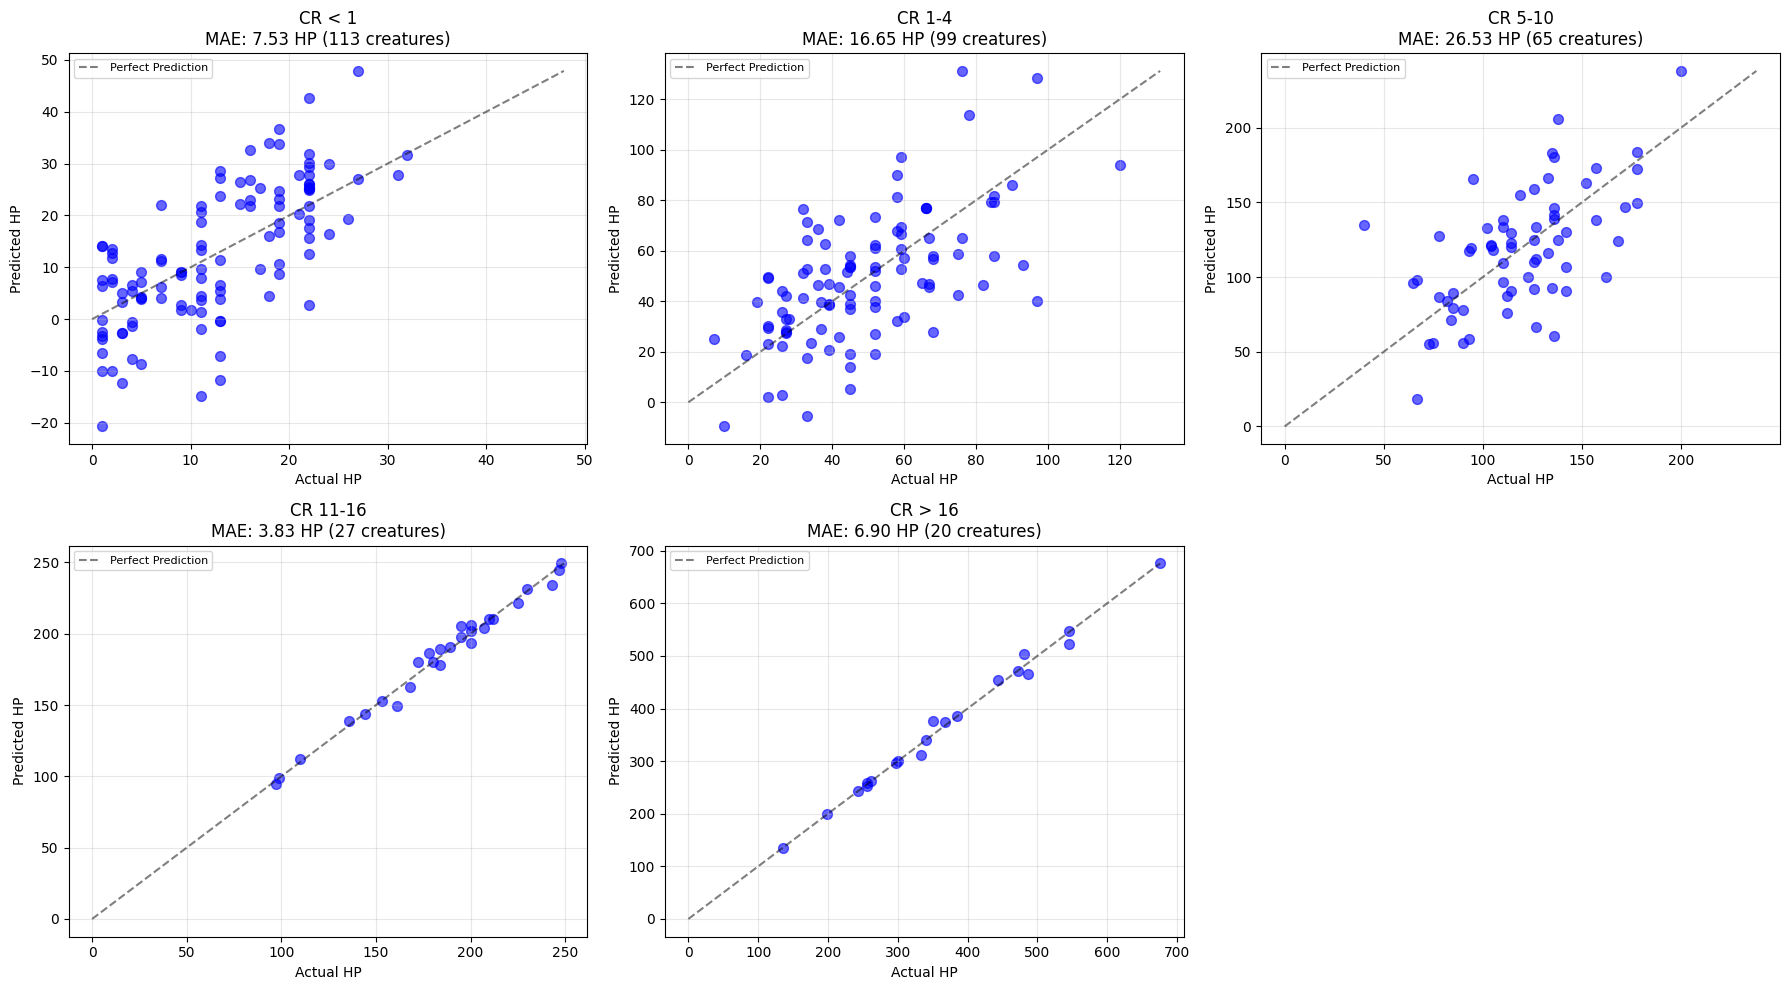


📊 VISUALIZATION: Error Distribution (5 CR Buckets)


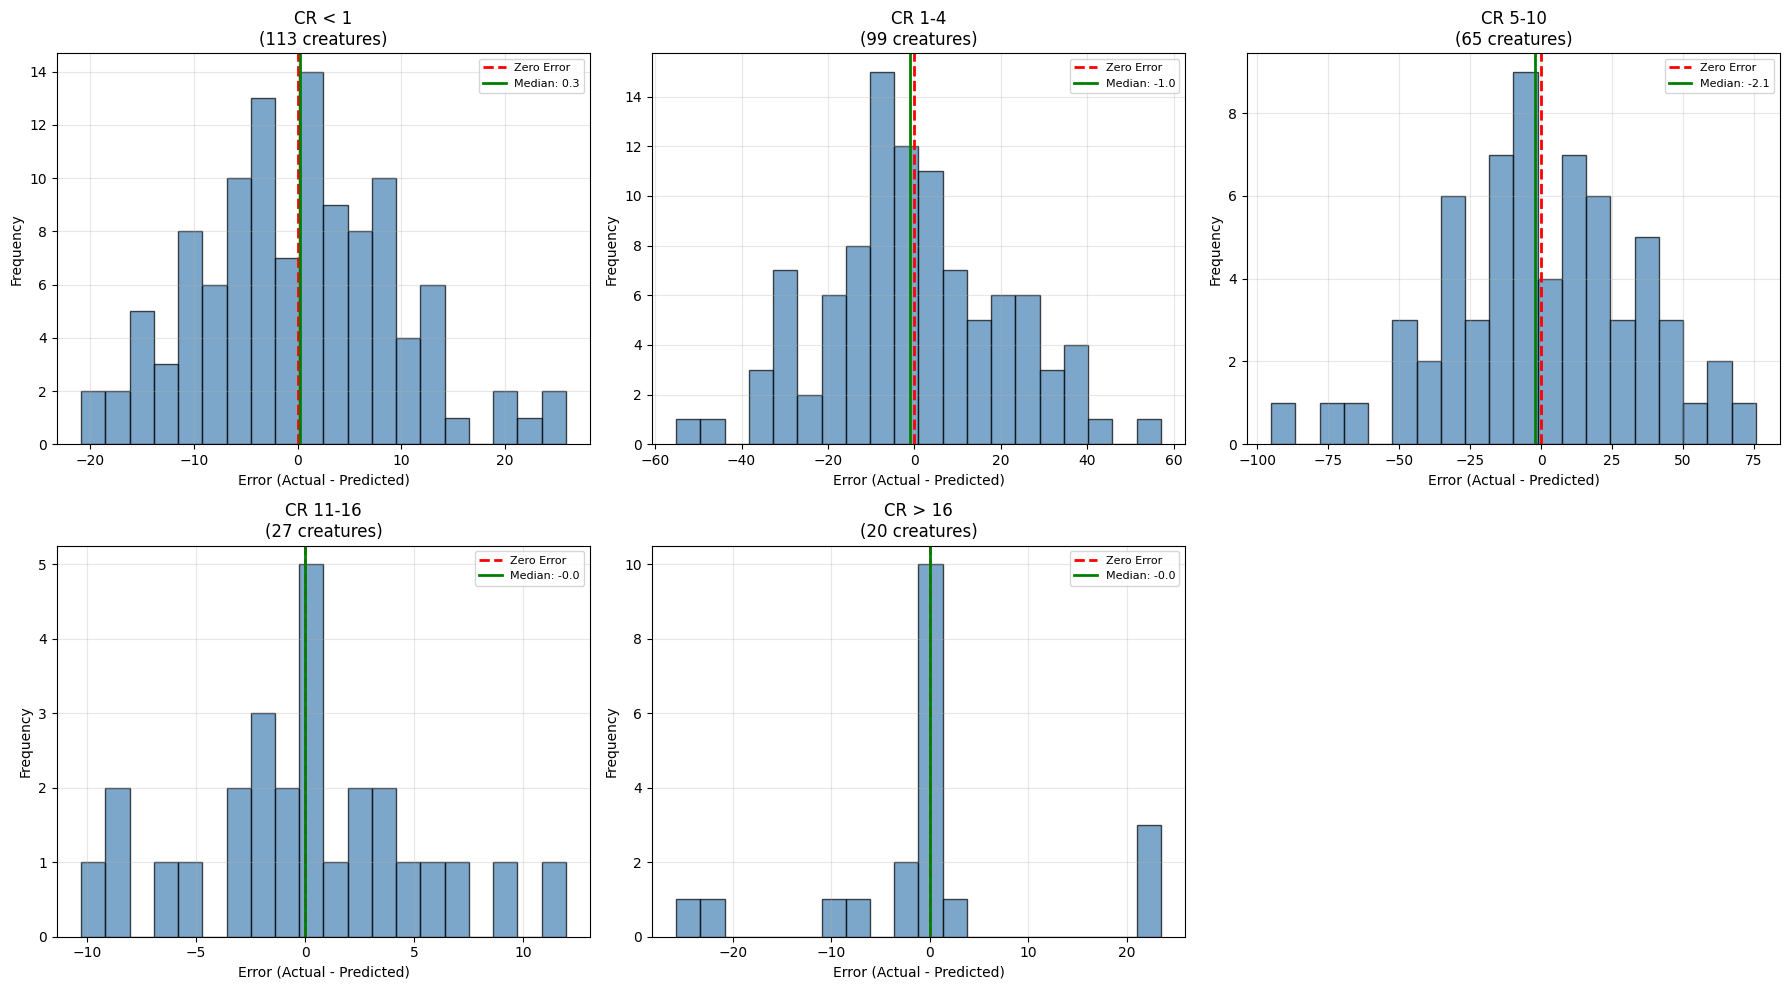

In [94]:
print("🔍 ANALYZING BEST AND WORST PREDICTIONS")
print("=" * 80)

def analyze_predictions(df_tier, y_actual, y_pred, tier_name):
    """Analyze prediction accuracy for a tier."""
    # Create analysis dataframe
    analysis = pd.DataFrame({
        'Name': df_tier['Name'].values,
        'CR': df_tier['cr_numeric'].values,
        'Actual_HP': y_actual,
        'Predicted_HP': y_pred,
        'Error': y_actual - y_pred,
        'Abs_Error': np.abs(y_actual - y_pred),
        'Pct_Error': ((y_actual - y_pred) / y_actual) * 100
    })
    
    # Sort by absolute error
    analysis = analysis.sort_values('Abs_Error')
    
    # Get best and worst 10
    best_10 = analysis.head(10)
    worst_10 = analysis.tail(10)
    
    print(f"\n{tier_name} - Best 10 Predictions:")
    print(best_10[['Name', 'CR', 'Actual_HP', 'Predicted_HP', 'Error']].to_string(index=False))
    
    print(f"\n{tier_name} - Worst 10 Predictions:")
    print(worst_10[['Name', 'CR', 'Actual_HP', 'Predicted_HP', 'Error']].to_string(index=False))
    
    # Summary stats
    print(f"\n{tier_name} Summary:")
    print(f"  Total creatures: {len(analysis)}")
    print(f"  Mean Absolute Error: {analysis['Abs_Error'].mean():.2f} HP")
    print(f"  Median Absolute Error: {analysis['Abs_Error'].median():.2f} HP")
    print(f"  Max Error: {analysis['Abs_Error'].max():.2f} HP")
    print(f"  Mean % Error: {analysis['Pct_Error'].abs().mean():.2f}%")
    
    return analysis

# Analyze each CR bucket

# CR < 1
X_cr1_scaled = scaler_cr1.transform(X_cr1)
y_pred_cr1_residual = model_cr1.predict(X_cr1_scaled)
y_actual_cr1_full = df_cr1['actual_hp'].values
y_pred_cr1_full = df_cr1['hp_after_phase2'].values + y_pred_cr1_residual
analysis_cr1 = analyze_predictions(df_cr1, y_actual_cr1_full, y_pred_cr1_full, "CR < 1")

# CR 1-4
X_cr2_scaled = scaler_cr2.transform(X_cr2)
y_pred_cr2_residual = model_cr2.predict(X_cr2_scaled)
y_actual_cr2_full = df_cr2['actual_hp'].values
y_pred_cr2_full = df_cr2['hp_after_phase2'].values + y_pred_cr2_residual
analysis_cr2 = analyze_predictions(df_cr2, y_actual_cr2_full, y_pred_cr2_full, "CR 1-4")

# CR 5-10
X_cr3_scaled = scaler_cr3.transform(X_cr3)
y_pred_cr3_residual = model_cr3.predict(X_cr3_scaled)
y_actual_cr3_full = df_cr3['actual_hp'].values
y_pred_cr3_full = df_cr3['hp_after_phase2'].values + y_pred_cr3_residual
analysis_cr3 = analyze_predictions(df_cr3, y_actual_cr3_full, y_pred_cr3_full, "CR 5-10")

# CR 11-16
X_cr4_scaled = scaler_cr4.transform(X_cr4)
y_pred_cr4_residual = model_cr4.predict(X_cr4_scaled)
y_actual_cr4_full = df_cr4['actual_hp'].values
y_pred_cr4_full = df_cr4['hp_after_phase2'].values + y_pred_cr4_residual
analysis_cr4 = analyze_predictions(df_cr4, y_actual_cr4_full, y_pred_cr4_full, "CR 11-16")

# CR > 16
X_cr5_scaled = scaler_cr5.transform(X_cr5)
y_pred_cr5_residual = model_cr5.predict(X_cr5_scaled)
y_actual_cr5_full = df_cr5['actual_hp'].values
y_pred_cr5_full = df_cr5['hp_after_phase2'].values + y_pred_cr5_residual
analysis_cr5 = analyze_predictions(df_cr5, y_actual_cr5_full, y_pred_cr5_full, "CR > 16")

# Create visualizations - 5 CR buckets
print("\n" + "=" * 80)
print("📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Helper function for scatter plots
def plot_scatter(ax, analysis, title):
    ax.scatter(analysis['Actual_HP'], analysis['Predicted_HP'],
               alpha=0.6, s=50, color='blue')
    max_val = max(analysis['Actual_HP'].max(), analysis['Predicted_HP'].max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect Prediction')
    ax.set_xlabel('Actual HP')
    ax.set_ylabel('Predicted HP')
    ax.set_title(f'{title}\nMAE: {analysis["Abs_Error"].mean():.2f} HP ({len(analysis)} creatures)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plot_scatter(axes[0], analysis_cr1, 'CR < 1')
plot_scatter(axes[1], analysis_cr2, 'CR 1-4')
plot_scatter(axes[2], analysis_cr3, 'CR 5-10')
plot_scatter(axes[3], analysis_cr4, 'CR 11-16')
plot_scatter(axes[4], analysis_cr5, 'CR > 16')

# Hide the 6th subplot (empty)
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Error distribution plots - 5 CR buckets
print("\n" + "=" * 80)
print("📊 VISUALIZATION: Error Distribution (5 CR Buckets)")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Helper function for error histograms
def plot_error_hist(ax, analysis, title):
    ax.hist(analysis['Error'], bins=20, alpha=0.7, 
            color='steelblue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax.axvline(x=analysis['Error'].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {analysis["Error"].median():.1f}')
    ax.set_xlabel('Error (Actual - Predicted)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title}\n({len(analysis)} creatures)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plot_error_hist(axes[0], analysis_cr1, 'CR < 1')
plot_error_hist(axes[1], analysis_cr2, 'CR 1-4')
plot_error_hist(axes[2], analysis_cr3, 'CR 5-10')
plot_error_hist(axes[3], analysis_cr4, 'CR 11-16')
plot_error_hist(axes[4], analysis_cr5, 'CR > 16')

# Hide the 6th subplot (empty)
axes[5].axis('off')

plt.tight_layout()
plt.show()


## Create Exportable and Interpretable export_df

In [95]:
print("\n📊 EXPORTING ENGINEERED FEATURES TO CSV")
print("=" * 80)

# Combine all five CR tiers back into one dataframe
export_df = pd.concat([df_cr1, df_cr2, df_cr3, df_cr4, df_cr5], ignore_index=False)

# Add predicted HP for all creatures
def get_prediction_for_creature(row):
    """Get the final HP prediction for a creature based on its CR tier."""
    cr = row['cr_numeric']
    
    # Get features and handle NaN values properly to avoid FutureWarning
    X = row[phase3_features].to_frame().T.fillna(0).infer_objects(copy=False).values.reshape(1, -1)
    
    if cr < 1.0:
        X_scaled = scaler_cr1.transform(X)
        residual_pred = model_cr1.predict(X_scaled)[0]
    elif cr <= 4.0:
        X_scaled = scaler_cr2.transform(X)
        residual_pred = model_cr2.predict(X_scaled)[0]
    elif cr <= 10.0:
        X_scaled = scaler_cr3.transform(X)
        residual_pred = model_cr3.predict(X_scaled)[0]
    elif cr <= 16.0:
        X_scaled = scaler_cr4.transform(X)
        residual_pred = model_cr4.predict(X_scaled)[0]
    else:
        X_scaled = scaler_cr5.transform(X)
        residual_pred = model_cr5.predict(X_scaled)[0]
    
    return row['hp_after_phase2'] + residual_pred

export_df['predicted_hp'] = export_df.apply(get_prediction_for_creature, axis=1)

# Add hp_delta (predicted - actual)
export_df['hp_delta'] = export_df['predicted_hp'] - export_df['actual_hp']

# Add hp_delta_pct (delta as % of actual HP)
export_df['hp_delta_pct'] = (export_df['hp_delta'] / export_df['actual_hp']) * 100

# Add percentile of hp_delta_pct within each CR tier
def add_percentile_by_cr(df):
    """Add percentile ranking of absolute hp_delta_pct within each CR bucket."""
    df['hp_delta_pct_percentile'] = 0.0
    
    # CR < 1 percentile
    cr1_mask = df['cr_numeric'] < 1.0
    if cr1_mask.any():
        abs_pct = df.loc[cr1_mask, 'hp_delta_pct'].abs()
        df.loc[cr1_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    # CR 1-4 percentile
    cr2_mask = (df['cr_numeric'] >= 1.0) & (df['cr_numeric'] <= 4.0)
    if cr2_mask.any():
        abs_pct = df.loc[cr2_mask, 'hp_delta_pct'].abs()
        df.loc[cr2_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    # CR 5-10 percentile
    cr3_mask = (df['cr_numeric'] > 4.0) & (df['cr_numeric'] <= 10.0)
    if cr3_mask.any():
        abs_pct = df.loc[cr3_mask, 'hp_delta_pct'].abs()
        df.loc[cr3_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    # CR 11-16 percentile
    cr4_mask = (df['cr_numeric'] > 10.0) & (df['cr_numeric'] <= 16.0)
    if cr4_mask.any():
        abs_pct = df.loc[cr4_mask, 'hp_delta_pct'].abs()
        df.loc[cr4_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    # CR > 16 percentile
    cr5_mask = df['cr_numeric'] > 16.0
    if cr5_mask.any():
        abs_pct = df.loc[cr5_mask, 'hp_delta_pct'].abs()
        df.loc[cr5_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    return df

export_df = add_percentile_by_cr(export_df)

# Select columns to export
columns_to_export = [
    # Identifying information
    'Name', 'Type', 'Size', 'Challenge_Rating', 'cr_numeric',
    
    # Original stats
    'HP', 'actual_hp', 'AC', 'ac_value',
    
    # Predictions and errors
    'predicted_hp', 'hp_delta', 'hp_delta_pct', 'hp_delta_pct_percentile',
    
    # Baselines
    'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline', 'dc_baseline',
    
    # Combat stats
    'highest_attack_bonus', 'highest_save_dc', 'estimated_dpr', 'legendary_dpr', 'total_dpr',
    
    # Phase 2: Deviations
    'ac_deviation', 'attack_deviation', 'dpr_deviation', 'save_dc_deviation',
    
    # Phase intermediates
    'hp_after_phase1_5', 'hp_after_phase2', 'residual_hp',
    
    # Phase 3: Scaled features (if they exist)
    'has_legendary_resistance_scaled', 
    'has_magic_resistance_scaled', 'has_regeneration_scaled',
    
    # Phase 3: Movement
    'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb',
    'max_speed', 'movement_types_count', 'has_flying',
    
    # Phase 3: Defenses
    'save_proficiency_count', 'skill_proficiency_count',
    'resistance_count', 'immunity_count', 'vulnerability_count', 
    'condition_immunity_count',
    
    # Phase 3: Senses
    'has_darkvision', 'darkvision_deviation', 'has_blindsight', 
    'has_truesight', 'has_tremorsense', 'passive_perception',
    
    # Phase 3: Abilities
    'trait_count', 'action_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'legendary_actions_per_round',
    'total_ability_count',
    
    # Phase 3: Special abilities
    'has_legendary_actions', 'has_legendary_resistance', 
    'has_magic_resistance', 'has_regeneration',
    'has_spellcasting', 'spellcaster_level',
    'size_ordinal', 'has_grapple',
    
    # Phase 3: Condition infliction
    'inflicts_poisoned', 'inflicts_blinded', 'inflicts_charmed',
    'inflicts_deafened', 'inflicts_frightened', 'inflicts_incapacitated',
    'inflicts_paralyzed', 'inflicts_petrified', 'inflicts_prone',
    'inflicts_restrained', 'inflicts_stunned'
]

# Filter to only columns that exist in the dataframe
existing_columns = [col for col in columns_to_export if col in export_df.columns]
export_data = export_df[existing_columns].copy()

# Sort by CR for easier inspection
export_data = export_data.sort_values('cr_numeric')

# Export to CSV
output_path = f'{DATA_DIR}/engineered_features.csv'
export_data.to_csv(output_path, index=False)

print(f"✅ Exported {len(export_data)} monsters with {len(existing_columns)} features")
print(f"✅ Saved to: {output_path}")

print("\n📋 Exported Columns:")
print(f"   - Identification: Name, Type, Size, CR")
print(f"   - Predictions: predicted_hp, hp_delta, hp_delta_pct, hp_delta_pct_percentile")
print(f"   - Original Stats: HP, AC, Attack, DPR, Save DC")
print(f"   - Baselines: hp_baseline, ac_baseline, etc.")
print(f"   - Phase intermediates: hp_after_phase1_5, hp_after_phase2, residual_hp")
print(f"   - Phase 3: All {len(phase3_features)} engineered features")

print(f"\n🔍 Sample of exported data:")
display(export_data[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta', 
                      'hp_delta_pct', 'hp_delta_pct_percentile']].head(15))


📊 EXPORTING ENGINEERED FEATURES TO CSV


/tmp/ipykernel_3602/1480213671.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = row[phase3_features].to_frame().T.fillna(0).infer_objects(copy=False).values.reshape(1, -1)
/workspaces/matrix_v0/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_3602/1480213671.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = row[phase3_features].to_frame().T.fillna(0).infer_objects(copy=False).values.reshape(

✅ Exported 324 monsters with 79 features
✅ Saved to: data/engineered_features.csv

📋 Exported Columns:
   - Identification: Name, Type, Size, CR
   - Predictions: predicted_hp, hp_delta, hp_delta_pct, hp_delta_pct_percentile
   - Original Stats: HP, AC, Attack, DPR, Save DC
   - Baselines: hp_baseline, ac_baseline, etc.
   - Phase intermediates: hp_after_phase1_5, hp_after_phase2, residual_hp
   - Phase 3: All 39 engineered features

🔍 Sample of exported data:


,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile
39,Awakened Shrub,0.0,10,1.758361,-8.241639,-82.416387,62.831858
96,Deer,0.0,4,5.333765,1.333765,33.344127,34.513274
112,Eagle,0.0,3,-2.714359,-5.714359,-190.478618,81.415929
125,Frog,0.0,1,14.174647,13.174647,1317.464672,99.115044
142,Giant Fire Beetle,0.0,4,-0.649967,-4.649967,-116.249174,75.221239
273,Rat,0.0,1,14.080652,13.080652,1308.065234,98.230088
274,Raven,0.0,1,-3.248668,-4.248668,-424.866764,88.495575
251,Owl,0.0,1,7.621737,6.621737,662.173691,95.575221
244,Octopus,0.0,3,-12.268395,-15.268395,-508.946504,91.150442
197,Homunculus,0.0,5,-8.726436,-13.726436,-274.528730,84.955752


## Export Feature contributions

In [96]:
print("\n📊 EXPORTING FEATURE CONTRIBUTIONS TO CSV")
print("=" * 80)

# Combine all three CR tiers
all_creatures = pd.concat([df_cr1, df_cr2, df_cr3, df_cr4, df_cr5], ignore_index=False)

# Create feature contributions dataframe
contributions_list = []

for idx, row in all_creatures.iterrows():
    cr = row['cr_numeric']
    creature_data = {
        'Name': row['Name'],
        'CR': cr,
        'actual_hp': row['actual_hp'],
        'hp_baseline': row['hp_baseline'],
    }
    
    # Phase 1.5 contributions (resistances/immunities)
    creature_data['phase1_5_resistance_penalty'] = -row.get('resistance_penalty', 0)
    creature_data['phase1_5_immunity_penalty'] = -row.get('immunity_penalty', 0)
    creature_data['phase1_5_total_penalty'] = -row.get('total_defensive_penalty', 0)
    creature_data['hp_after_phase1_5'] = row.get('hp_after_phase1_5', row['hp_baseline'])
    
    # Phase 2 contributions (combat stat deviations + flying)
    if cr < 1.0:
        penalties = PHASE2_PENALTIES_CR1
    elif cr <= 4.0:
        model = model_cr2
        scaler = scaler_cr2
        penalties = PHASE2_PENALTIES_CR2
    elif cr <= 10.0:
        penalties = PHASE2_PENALTIES_CR2
    else:
        penalties = PHASE2_PENALTIES_CR3
    
    creature_data['phase2_ac_contribution'] = row['ac_deviation'] * penalties['ac_deviation']
    creature_data['phase2_attack_contribution'] = row['attack_deviation'] * penalties['attack_deviation']
    creature_data['phase2_dpr_contribution'] = row['dpr_deviation'] * penalties['dpr_deviation']
    creature_data['phase2_save_dc_contribution'] = row['save_dc_deviation'] * penalties['save_dc_deviation']
    creature_data['phase2_flying_contribution'] = row['has_flying'] * penalties['has_flying']
    creature_data['phase2_total_contribution'] = sum([
        creature_data['phase2_ac_contribution'],
        creature_data['phase2_attack_contribution'],
        creature_data['phase2_dpr_contribution'],
        creature_data['phase2_save_dc_contribution'],
        creature_data['phase2_flying_contribution']
    ])
    creature_data['hp_after_phase2'] = row['hp_after_phase2']
    
    # Phase 3 contributions (learned features)
    # Get the features and model for this CR tier
    if cr < 1.0:
        model = model_cr1
        scaler = scaler_cr1
    elif cr <= 4.0:
        model = model_cr2
        scaler = scaler_cr2
        penalties = PHASE2_PENALTIES_CR2
    elif cr <= 10.0:
        model = model_cr2
        scaler = scaler_cr2
    else:
        model = model_cr3
        scaler = scaler_cr3
    
    # Get feature values
    X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
    X_scaled = scaler.transform(X_features)
    
    # Calculate contribution of each feature
    coefficients = model.coef_
    intercept = model.intercept_
    
    # Feature contributions = scaled_feature * coefficient
    feature_contributions = X_scaled[0] * coefficients
    
    # Add intercept contribution
    creature_data['phase3_intercept'] = intercept
    
    # Add individual feature contributions
    for feat_name, contrib in zip(phase3_features, feature_contributions):
        creature_data[f'phase3_{feat_name}'] = contrib
    
    # Total Phase 3 contribution (residual)
    creature_data['phase3_total_contribution'] = intercept + feature_contributions.sum()
    
    # Final prediction
    creature_data['predicted_hp'] = row['hp_after_phase2'] + creature_data['phase3_total_contribution']
    creature_data['hp_error'] = creature_data['actual_hp'] - creature_data['predicted_hp']
    creature_data['hp_error_pct'] = (creature_data['hp_error'] / creature_data['actual_hp']) * 100
    
    contributions_list.append(creature_data)

# Create dataframe
contributions_df = pd.DataFrame(contributions_list)

# Save to CSV
output_path = f'{DATA_DIR}/feature_contributions.csv'
contributions_df.to_csv(output_path, index=False)

print(f"✅ Saved feature contributions to: {output_path}")
print(f"   Rows: {len(contributions_df)}")
print(f"   Columns: {len(contributions_df.columns)}")
print(f"\n   Columns include:")
print(f"     - Basic info: Name, CR, actual_hp, hp_baseline")
print(f"     - Phase 1.5: resistance/immunity penalties")
print(f"     - Phase 2: AC, attack, DPR, save DC, flying contributions")
print(f"     - Phase 3: Intercept + {len(phase3_features)} feature contributions")
print(f"     - Final: predicted_hp, hp_error, hp_error_pct")



📊 EXPORTING FEATURE CONTRIBUTIONS TO CSV


/tmp/ipykernel_3602/968347334.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
/workspaces/matrix_v0/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_3602/968347334.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
/workspaces/matrix_v0/.venv/lib/python3.12/site-package

✅ Saved feature contributions to: data/feature_contributions.csv
   Rows: 324
   Columns: 59

   Columns include:
     - Basic info: Name, CR, actual_hp, hp_baseline
     - Phase 1.5: resistance/immunity penalties
     - Phase 2: AC, attack, DPR, save DC, flying contributions
     - Phase 3: Intercept + 39 feature contributions
     - Final: predicted_hp, hp_error, hp_error_pct


/tmp/ipykernel_3602/968347334.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
/workspaces/matrix_v0/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_3602/968347334.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
/workspaces/matrix_v0/.venv/lib/python3.12/site-package

# Feature Contribution Analysis

Detailed analysis of feature contributions for creatures with high prediction errors.

In [97]:
print("=" * 80)
print("📊 FEATURE CONTRIBUTION ANALYSIS")
print("=" * 80)

# Show top 10 creatures with highest absolute error
print("\nTOP 10 CREATURES WITH HIGHEST ABSOLUTE ERROR:")
print("-" * 80)

contributions_df['abs_error'] = contributions_df['hp_error'].abs()
top_10 = contributions_df.nlargest(10, 'abs_error')[
    ['Name', 'CR', 'actual_hp', 'predicted_hp', 'hp_error', 
     'phase2_total_contribution', 'phase3_total_contribution']
].copy()

for col in ['predicted_hp', 'hp_error', 'phase2_total_contribution', 'phase3_total_contribution']:
    top_10[col] = top_10[col].round(2)

print(top_10.to_string(index=False))

# Detailed breakdown function
def show_creature_breakdown(creature_name):
    """Show detailed feature contribution breakdown for a creature."""
    creature = contributions_df[contributions_df['Name'] == creature_name].iloc[0]
    
    print(f"\n{'=' * 80}")
    print(f"DETAILED BREAKDOWN: {creature_name}")
    print("=" * 80)
    print()
    print(f"Actual HP: {creature['actual_hp']:.0f}")
    print(f"Predicted HP: {creature['predicted_hp']:.2f}")
    print(f"Error: {creature['hp_error']:.2f} HP ({creature['hp_error_pct']:.2f}%)")
    print()
    
    print("PHASE BREAKDOWN:")
    print("-" * 80)
    print(f"Baseline (Phase 1):                    {creature['hp_baseline']:>8.0f}")
    print()
    
    print("Phase 1.5 (Resistances/Immunities):")
    print(f"  Resistance penalty:                  {creature['phase1_5_resistance_penalty']:>8.0f}")
    print(f"  Immunity penalty:                    {creature['phase1_5_immunity_penalty']:>8.0f}")
    print(f"  Total defensive penalty:             {creature['phase1_5_total_penalty']:>8.0f}")
    print(f"  After Phase 1.5:                     {creature['hp_after_phase1_5']:>8.0f}")
    print()
    
    print("Phase 2 (Combat Stats):")
    print(f"  AC deviation contribution:           {creature['phase2_ac_contribution']:>8.0f}")
    print(f"  Attack deviation contribution:       {creature['phase2_attack_contribution']:>8.0f}")
    print(f"  DPR deviation contribution:          {creature['phase2_dpr_contribution']:>8.0f}")
    print(f"  Save DC deviation contribution:      {creature['phase2_save_dc_contribution']:>8.0f}")
    print(f"  Flying contribution:                 {creature['phase2_flying_contribution']:>8.0f}")
    print(f"  Phase 2 total:                       {creature['phase2_total_contribution']:>8.0f}")
    print(f"  After Phase 2:                       {creature['hp_after_phase2']:>8.0f}")
    print()
    
    print("Phase 3 (Learned Features) - Top 15 contributors:")
    # Get all phase3 feature contributions
    phase3_cols = [col for col in contributions_df.columns if col.startswith('phase3_') 
                   and col not in ['phase3_intercept', 'phase3_total_contribution']]
    
    phase3_contribs = []
    for feat in phase3_cols:
        feat_name = feat.replace('phase3_', '')
        value = creature[feat]
        if abs(value) > 0.01:  # Only show non-zero contributions
            phase3_contribs.append((feat_name, value))
    
    # Sort by absolute contribution
    phase3_contribs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Show top 15
    for feat_name, value in phase3_contribs[:15]:
        print(f"  {feat_name:40s} {value:>8.2f}")
    
    print()
    print(f"  Intercept:                           {creature['phase3_intercept']:>8.2f}")
    print(f"  Phase 3 total:                       {creature['phase3_total_contribution']:>8.2f}")
    print()
    
    print("-" * 80)
    print(f"FINAL PREDICTED HP:                    {creature['predicted_hp']:>8.2f}")
    print(f"ACTUAL HP:                             {creature['actual_hp']:>8.0f}")
    print(f"ERROR:                                 {creature['hp_error']:>8.2f}")

# Show detailed breakdowns for top 3 worst predictions
print("\n" + "=" * 80)
print("DETAILED BREAKDOWNS FOR TOP 3 WORST PREDICTIONS")
print("=" * 80)

for idx, row in top_10.head(3).iterrows():
    show_creature_breakdown(row['Name'])

# Show summary statistics
print("\n" + "=" * 80)
print("SUMMARY: Feature Contribution Patterns")
print("=" * 80)

print("\nPhase 2 contribution statistics:")
for col in ['phase2_ac_contribution', 'phase2_attack_contribution', 
            'phase2_dpr_contribution', 'phase2_save_dc_contribution', 'phase2_flying_contribution']:
    mean_val = contributions_df[col].mean()
    std_val = contributions_df[col].std()
    print(f"  {col:40s} μ={mean_val:>7.2f}  σ={std_val:>7.2f}")

print("\nPhase 3 contribution statistics:")
phase3_mean = contributions_df['phase3_total_contribution'].mean()
phase3_std = contributions_df['phase3_total_contribution'].std()
print(f"  Phase 3 total contribution:            μ={phase3_mean:>7.2f}  σ={phase3_std:>7.2f}")

print("\n" + "=" * 80)
print("✅ Feature contribution analysis complete")
print("   See data/feature_contributions.csv for full details")
print("=" * 80)


📊 FEATURE CONTRIBUTION ANALYSIS

TOP 10 CREATURES WITH HIGHEST ABSOLUTE ERROR:
--------------------------------------------------------------------------------
                 Name   CR  actual_hp  predicted_hp  hp_error  phase2_total_contribution  phase3_total_contribution
            Tarrasque 30.0        676       1231.97   -555.97                     508.00                    -273.33
                 Lich 21.0        135        589.66   -454.66                     371.25                    -347.59
               Kraken 23.0        472        856.71   -384.71                     266.25                      30.96
  Ancient Blue Dragon 23.0        481        782.26   -301.26                     244.50                      -5.49
  Ancient Gold Dragon 24.0        546        823.06   -277.06                     287.00                     -59.94
                Balor 19.0        262        538.97   -276.97                     154.25                      -8.28
             Rakshasa 13.0  

# Individual Creature Analysis

In [98]:
export_df[export_df['cr_numeric'].between(2,5)].sort_values('predicted_hp').loc[:, ['predicted_hp']+list(export_df.columns)].head()

,predicted_hp,Name,Size,Type,Alignment,HP,AC,Speed,Challenge_Rating,XP,...,family,hp_after_phase2,has_legendary_resistance_scaled,has_magic_resistance_scaled,has_regeneration_scaled,residual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile
363,5.186051,Wight,Medium,undead,Neutral Evil,45 (6d8+18),14 (Studded Leather),30 ft.,3,700,...,other,14.50,0.0,0.00,0.0,30.50,5.186051,-39.813949,-88.475443,87.878788
75,14.091759,Centaur,Large,monstrosity,Neutral Good,45 (6d10+12),12,50 ft.,2,450,...,other,20.00,0.0,0.00,0.0,25.00,14.091759,-30.908241,-68.684979,83.838384
90,17.614061,Cult Fanatic,Medium,humanoid (any race),Any Non-good Alignment,33 (6d8+6),13 (Leather Armor),30 ft.,2,450,...,other,96.00,0.0,0.00,0.0,-63.00,17.614061,-15.385939,-46.624058,70.707071
342,18.659828,Unicorn,Large,celestial,Lawful Good,67 (9d10+18),12,50 ft.,5,"1,800",...,other,89.25,0.0,89.25,0.0,-22.25,18.659828,-48.340172,-72.149510,96.923077
127,18.909750,Gargoyle,Medium,elemental,Chaotic Evil,52 (7d8+21),15 (Natural Armor),"30 ft., fly 60 ft.",2,450,...,other,13.50,0.0,0.00,0.0,38.50,18.909750,-33.090250,-63.635096,80.808081


## investigate_creature Function

In [99]:
def investigate_creature(creature_name):
    """
    Display a streamlined breakdown of a creature's HP prediction.
    Shows actual features and their HP impacts side-by-side.
    """
    # Get creature data from both dataframes
    creature_contrib = contributions_df[contributions_df['Name'] == creature_name]
    creature_export = export_df[export_df['Name'] == creature_name]
    
    if len(creature_contrib) == 0:
        print(f"Creature '{creature_name}' not found!")
        return
    
    creature_contrib = creature_contrib.iloc[0]
    creature_export = creature_export.iloc[0]
    
    print("="*80)
    print(f"  {creature_name.upper()} (CR {creature_contrib['CR']})")
    print("="*80)
    print()
    
    # Summary
    print(f"Actual HP:        {creature_contrib['actual_hp']:>8.0f}")
    print(f"Predicted HP:     {creature_contrib['predicted_hp']:>8.0f}")
    print(f"Error:            {creature_contrib['hp_error']:>8.0f}  ({creature_contrib['hp_error_pct']:>6.1f}%)")
    print()
    print("─"*80)
    
    # Phase 1: Baseline
    print(f"\nPHASE 1: CR BASELINE")
    print(f"  HP Baseline (CR {creature_contrib['CR']}):                          {creature_contrib['hp_baseline']:>8.0f}")
    
    # Phase 1.5: Resistances/Immunities
    print(f"\nPHASE 1.5: RESISTANCES & IMMUNITIES")
    res_penalty = creature_contrib['phase1_5_resistance_penalty']
    imm_penalty = creature_contrib['phase1_5_immunity_penalty']
    
    if res_penalty != 0 or imm_penalty != 0:
        print(f"  Resistance Penalty:                              {res_penalty:>8.0f}")
        print(f"  Immunity Penalty:                                {imm_penalty:>8.0f}")
        print(f"  Total Penalty:                                   {creature_contrib['phase1_5_total_penalty']:>8.0f}")
    else:
        print(f"  No resistances or immunities")
    print(f"  HP after Phase 1.5:                              {creature_contrib['hp_after_phase1_5']:>8.0f}")
    
    # Phase 2: Combat Stats
    print(f"\nPHASE 2: COMBAT STATS")
    combat_stats = [
        ('AC Contribution', 'phase2_ac_contribution'),
        ('Attack Bonus Contribution', 'phase2_attack_contribution'),
        ('DPR Contribution', 'phase2_dpr_contribution'),
        ('Save DC Contribution', 'phase2_save_dc_contribution'),
        ('Flying Contribution', 'phase2_flying_contribution'),
    ]
    
    for label, col in combat_stats:
        val = creature_contrib[col]
        if val != 0:
            print(f"  {label:<45} {val:>8.0f}")
    
    print(f"  {'─'*53}")
    print(f"  Phase 2 Total:                                   {creature_contrib['phase2_total_contribution']:>8.0f}")
    print(f"  HP after Phase 2:                                {creature_contrib['hp_after_phase2']:>8.0f}")
    
    # Phase 3: Individual Features (show ALL features)
    print(f"\nPHASE 3: INDIVIDUAL FEATURES")
    
    # Get all phase3 columns (excluding intercept and total)
    phase3_cols = [col for col in contributions_df.columns 
                   if col.startswith('phase3_') 
                   and col != 'phase3_total_contribution' 
                   and col != 'phase3_intercept']
    
    # Show all features with their actual values and HP impacts
    for col in phase3_cols:
        feature_name = col.replace('phase3_', '')
        hp_impact = creature_contrib[col]
        
        # Get the actual feature value from export_df
        if feature_name in creature_export.index:
            feature_value = creature_export[feature_name]
        else:
            feature_value = 'N/A'
        
        # Format the output
        try:
            val_str = f"{float(feature_value):.1f}"
        except:
            val_str = str(feature_value)
        
        print(f"  Feature: {feature_name:<35} value: {val_str:>6}  hp impact: {hp_impact:>6.0f}")
    
    print(f"\n  Intercept:                                       {creature_contrib['phase3_intercept']:>8.0f}")
    print(f"  {'─'*53}")
    print(f"  Phase 3 Total:                                   {creature_contrib['phase3_total_contribution']:>8.0f}")
    
    print()
    print("="*80)
    print(f"  FINAL PREDICTED HP:                              {creature_contrib['predicted_hp']:>8.0f}")
    print(f"  ACTUAL HP:                                       {creature_contrib['actual_hp']:>8.0f}")
    print(f"  ERROR:                                           {creature_contrib['hp_error']:>8.0f}  ({creature_contrib['hp_error_pct']:>6.1f}%)")
    print("="*80)


## Investigations

In [104]:
# Example usage
investigate_creature('Elephant')

  ELEPHANT (CR 4.0)

Actual HP:              76
Predicted HP:          131
Error:                 -55  ( -72.6%)

────────────────────────────────────────────────────────────────────────────────

PHASE 1: CR BASELINE
  HP Baseline (CR 4.0):                               101

PHASE 1.5: RESISTANCES & IMMUNITIES
  No resistances or immunities
  HP after Phase 1.5:                                   101

PHASE 2: COMBAT STATS
  AC Contribution                                     10
  Attack Bonus Contribution                          -12
  DPR Contribution                                    11
  Save DC Contribution                                20
  ─────────────────────────────────────────────────────
  Phase 2 Total:                                         29
  HP after Phase 2:                                     130

PHASE 3: INDIVIDUAL FEATURES
  Feature: has_legendary_resistance_scaled     value:    0.0  hp impact:     -0
  Feature: has_magic_resistance_scaled         value:    0.0

In [101]:
_creature_index = export_df[export_df['Name']=='Elephant'].index
export_df.loc[_creature_index, [c for c in export_df.columns if 'dpr' in c]]

,estimated_dpr,legendary_dpr,total_dpr,dpr_baseline,dpr_deviation
115,22.5,0,22.5,28.0,-5.5


Stuff I tested
* Kobold
* Wyvern
* Green Hag
* Elephant

## Resumarize

In [102]:
summarize_models()


🎉 5-BUCKET HP MODEL TRAINING COMPLETE

📊 MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  -0.3805
      Test MAE: 7.53 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.0440
      Test MAE: 16.65 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  -0.0879
      Test MAE: 26.53 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.9843
      Test MAE: 3.83 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9921
      Test MAE: 6.90 HP

✅ All 5 models trained successfully!


## Investigating Outliers

In [103]:
# =============================================================================
# 🔍 INVESTIGATING OUTLIERS: High Deviation Features with Under-predicted HP
# =============================================================================
# This cell identifies creatures where:
# 1. Predicted HP is much lower than actual HP (model under-predicts)
# 2. They have unusually high values in deviation-like features
# These may indicate features that need overrides (like DC_OVERRIDES)

print("🔍 OUTLIER INVESTIGATION: Under-predicted HP with High Deviations")
print("=" * 80)

# Combine all analysis dataframes
all_analysis = pd.concat([analysis_cr1, analysis_cr2, analysis_cr3, analysis_cr4, analysis_cr5], ignore_index=True)

# Merge with main df to get deviation features
deviation_cols = [
    'save_dc_deviation', 'ac_deviation', 'attack_deviation', 'dpr_deviation',
    'size_ordinal_deviation', 'speed_ground_deviation', 'speed_fly_deviation'
]

# Get creatures where predicted HP is much less than actual (under-prediction)
# Error = Actual - Predicted, so positive error means under-prediction
under_predicted = all_analysis[all_analysis['Error'] > 20].copy()
under_predicted = under_predicted.merge(
    df[['Name'] + deviation_cols + ['highest_save_dc', 'ac_value', 'highest_attack_bonus', 'total_dpr']],
    on='Name', how='left'
)

print(f"\nFound {len(under_predicted)} creatures with Error > 20 HP (under-predicted)")
print("\n" + "-" * 80)

# Check for high save_dc_deviation (potential DC override candidates)
print("\n📊 HIGH SAVE DC DEVIATION (potential DC override candidates):")
print("-" * 60)
high_dc = under_predicted[under_predicted['save_dc_deviation'] > 3].sort_values('save_dc_deviation', ascending=False)
if len(high_dc) > 0:
    print(high_dc[['Name', 'CR', 'Error', 'highest_save_dc', 'save_dc_deviation']].head(15).to_string(index=False))
else:
    print("  No creatures found")

# Check for high ac_deviation
print("\n📊 HIGH AC DEVIATION:")
print("-" * 60)
high_ac = under_predicted[under_predicted['ac_deviation'] > 3].sort_values('ac_deviation', ascending=False)
if len(high_ac) > 0:
    print(high_ac[['Name', 'CR', 'Error', 'ac_value', 'ac_deviation']].head(15).to_string(index=False))
else:
    print("  No creatures found")

# Check for high attack_deviation
print("\n📊 HIGH ATTACK DEVIATION:")
print("-" * 60)
high_atk = under_predicted[under_predicted['attack_deviation'] > 3].sort_values('attack_deviation', ascending=False)
if len(high_atk) > 0:
    print(high_atk[['Name', 'CR', 'Error', 'highest_attack_bonus', 'attack_deviation']].head(15).to_string(index=False))
else:
    print("  No creatures found")

# Check for high dpr_deviation
print("\n📊 HIGH DPR DEVIATION:")
print("-" * 60)
high_dpr = under_predicted[under_predicted['dpr_deviation'] > 20].sort_values('dpr_deviation', ascending=False)
if len(high_dpr) > 0:
    print(high_dpr[['Name', 'CR', 'Error', 'total_dpr', 'dpr_deviation']].head(15).to_string(index=False))
else:
    print("  No creatures found")

# Summary table of worst under-predictions with all deviations
print("\n" + "=" * 80)
print("📊 WORST UNDER-PREDICTIONS WITH ALL DEVIATIONS:")
print("=" * 80)
worst_under = under_predicted.nlargest(20, 'Error')
display_cols = ['Name', 'CR', 'Actual_HP', 'Predicted_HP', 'Error', 
                'save_dc_deviation', 'ac_deviation', 'attack_deviation', 'dpr_deviation']
print(worst_under[display_cols].to_string(index=False))

# Identify potential override candidates
print("\n" + "=" * 80)
print("🎯 POTENTIAL OVERRIDE CANDIDATES:")
print("=" * 80)
print("Creatures with high deviations that may need manual review:")
print("(Check if high values are thematic rather than combat-relevant)\n")

candidates = under_predicted[
    (under_predicted['save_dc_deviation'] > 4) | 
    (under_predicted['ac_deviation'] > 4) |
    (under_predicted['attack_deviation'] > 4)
].sort_values('Error', ascending=False)

if len(candidates) > 0:
    for _, row in candidates.head(10).iterrows():
        print(f"  {row['Name']} (CR {row['CR']}):")
        print(f"    Error: {row['Error']:.0f} HP under-predicted")
        if row['save_dc_deviation'] > 4:
            print(f"    ⚠️  Save DC: {row['highest_save_dc']:.0f} (deviation: +{row['save_dc_deviation']:.1f})")
        if row['ac_deviation'] > 4:
            print(f"    ⚠️  AC: {row['ac_value']:.0f} (deviation: +{row['ac_deviation']:.1f})")
        if row['attack_deviation'] > 4:
            print(f"    ⚠️  Attack: +{row['highest_attack_bonus']:.0f} (deviation: +{row['attack_deviation']:.1f})")
        print()
else:
    print("  No obvious candidates found")


🔍 OUTLIER INVESTIGATION: Under-predicted HP with High Deviations

Found 42 creatures with Error > 20 HP (under-predicted)

--------------------------------------------------------------------------------

📊 HIGH SAVE DC DEVIATION (potential DC override candidates):
------------------------------------------------------------
         Name  CR    Error  highest_save_dc  save_dc_deviation
Giant Octopus 1.0 25.17639             16.0                4.0

📊 HIGH AC DEVIATION:
------------------------------------------------------------
                  Name   CR     Error  ac_value  ac_deviation
        Animated Armor 1.00 38.575271        18           6.0
                Couatl 4.00 56.988826        19           5.0
                 Roper 5.00 34.519397        20           5.0
                  Drow 0.25 24.684372        15           4.0
             Green Hag 3.00 35.666409        17           4.0
Silver Dragon Wyrmling 2.00 25.954558        17           4.0
                Drider 6.00 23